# Walk-Forward Validation — 6 Years of Data

Tests whether the stat arb edge is real or overfit by running anchored walk-forward validation
on 5.6 years of Binance Futures hourly data (Sep 2020 → Apr 2026).

**Three configurations compared:**
- **4-pair** (LINK/SOL, DOGE/AVAX, SOL/AVAX, BTC/SOL) — original strategy
- **3-pair** (drop BTC/SOL) — based on 2-year backtest showing BTC/SOL is a consistent drag
- **3-pair, 1y train** — shorter training window to capture regime sensitivity

**Metrics:**
- PSR (Probabilistic Sharpe Ratio): probability that the true Sharpe > 0
- DSR (Deflated Sharpe Ratio): PSR adjusted for 405 implicit trials (45 pair combos × 9 param sweeps)
- CVaR: expected loss in worst 5% / 1% of days
- Sortino: return per unit of downside risk

In [1]:
import sys
from pathlib import Path
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Find repo root by walking up from this notebook's directory to find pyproject.toml
def find_repo_root():
    """Find the repo root by looking for pyproject.toml."""
    # Try notebook dir first (works when opened from Jupyter file browser)
    candidates = [Path('.').resolve(), Path('..').resolve(), Path('../..').resolve()]
    for p in candidates:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'hypemm').exists():
            return p
    raise FileNotFoundError('Cannot find repo root. Run from the project directory.')

repo_root = find_repo_root()
sys.path.insert(0, str(repo_root / 'src'))

import os
os.chdir(repo_root)

from hypemm.config import load_config
from hypemm.data import load_candles
from hypemm.funding import load_funding
from hypemm.walkforward import (
    run_walk_forward,
    probabilistic_sharpe_ratio,
    deflated_sharpe_ratio,
    conditional_var,
    sortino_ratio,
)
from hypemm.backtest import run_backtest_all_pairs, summarize_backtest, compute_sharpe

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print(f'Repo root: {repo_root}')

Repo root: /Users/thomas/My_Projects/metaverse/hypemm


## Load Data

In [2]:
cfg_4pair = load_config(repo_root / 'configs' / 'backtest' / 'original_4pair_6y.toml')
cfg_3pair = load_config(repo_root / 'configs' / 'backtest' / 'original_3pair_6y.toml')

prices = load_candles(Path(cfg_4pair.infra.candles_dir), cfg_4pair.strategy.all_coins)
funding = load_funding(Path(cfg_4pair.infra.funding_dir), cfg_4pair.strategy.all_coins)

print(f'Loaded {len(prices):,} hourly bars')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Coins: {list(prices.columns)}')

Loaded 48,875 hourly bars
Date range: 2020-09-23 → 2026-04-21
Coins: ['AVAX', 'BTC', 'DOGE', 'LINK', 'SOL']


## Run Walk-Forward Validation

Three configurations:
1. **4-pair, 2y train** — original strategy with all pairs
2. **3-pair, 2y train** — drop BTC/SOL
3. **3-pair, 1y train** — drop BTC/SOL, shorter train window (adds an extra fold)

In [3]:
import logging
logging.basicConfig(level=logging.WARNING)

print('Running 4-pair, 2y train...')
wf_4pair = run_walk_forward(prices, cfg_4pair.strategy, funding=funding,
                            train_years=2, test_months=12, step_months=12)
print(f'  → {len(wf_4pair.windows)} folds, {wf_4pair.oos_trades} OOS trades\n')

print('Running 3-pair, 2y train...')
wf_3pair = run_walk_forward(prices, cfg_3pair.strategy, funding=funding,
                            train_years=2, test_months=12, step_months=12)
print(f'  → {len(wf_3pair.windows)} folds, {wf_3pair.oos_trades} OOS trades\n')

print('Running 3-pair, 1y train...')
wf_3pair_1y = run_walk_forward(prices, cfg_3pair.strategy, funding=funding,
                               train_years=1, test_months=12, step_months=12)
print(f'  → {len(wf_3pair_1y.windows)} folds, {wf_3pair_1y.oos_trades} OOS trades')

Running 4-pair, 2y train...


  → 4 folds, 2151 OOS trades

Running 3-pair, 2y train...


  → 4 folds, 1618 OOS trades

Running 3-pair, 1y train...


  → 5 folds, 2040 OOS trades


## Per-Fold Results Table

In [4]:
def fold_table(result, name):
    rows = []
    for w in result.windows:
        rows.append({
            'Fold': w.fold,
            'Test Period': f'{w.test_start} → {w.test_end}',
            'Train SR': w.train_sharpe,
            'Test SR': w.test_sharpe,
            'Test Net': w.test_net,
            'WR %': w.test_win_rate,
            'Max DD': w.test_max_dd,
            '$/day': w.test_daily_avg,
            'Trades': w.test_trades,
        })
    df = pd.DataFrame(rows)
    print(f'\n=== {name} ===')
    styled = df.style.format({
        'Train SR': '{:.2f}',
        'Test SR': '{:.2f}',
        'Test Net': '${:+,.0f}',
        'WR %': '{:.0f}%',
        'Max DD': '${:,.0f}',
        '$/day': '${:,.0f}',
    })
    styled = styled.map(
        lambda v: 'color: green' if isinstance(v, (int, float)) and v > 0 else
                  'color: red' if isinstance(v, (int, float)) and v < 0 else '',
        subset=['Test SR', 'Test Net', '$/day']
    )
    return styled

display(fold_table(wf_4pair, '4-Pair (LINK/SOL, DOGE/AVAX, SOL/AVAX, BTC/SOL) — 2y train'))
display(fold_table(wf_3pair, '3-Pair (drop BTC/SOL) — 2y train'))
display(fold_table(wf_3pair_1y, '3-Pair (drop BTC/SOL) — 1y train'))


=== 4-Pair (LINK/SOL, DOGE/AVAX, SOL/AVAX, BTC/SOL) — 2y train ===


,Fold,Test Period,Train SR,Test SR,Test Net,WR %,Max DD,$/day,Trades
0,0,2022-09-23 → 2023-09-23,-0.54,-2.28,"$-84,556",68%,"$108,392",$-232,542
1,1,2023-09-23 → 2024-09-23,-0.97,-0.86,"$-31,620",65%,"$43,284",$-86,509
2,2,2024-09-23 → 2025-09-23,-0.93,1.16,"$+41,817",70%,"$45,986",$115,644
3,3,2025-09-23 → 2026-04-21,-0.58,6.50,"$+104,054",77%,"$9,303",$495,456



=== 3-Pair (drop BTC/SOL) — 2y train ===


,Fold,Test Period,Train SR,Test SR,Test Net,WR %,Max DD,$/day,Trades
0,0,2022-09-23 → 2023-09-23,0.03,-2.11,"$-66,553",69%,"$85,411",$-182,408
1,1,2023-09-23 → 2024-09-23,-0.65,-0.42,"$-11,046",66%,"$25,430",$-30,380
2,2,2024-09-23 → 2025-09-23,-0.59,2.23,"$+64,888",72%,"$27,645",$178,489
3,3,2025-09-23 → 2026-04-21,-0.08,7.08,"$+91,748",79%,"$7,774",$437,341



=== 3-Pair (drop BTC/SOL) — 1y train ===


,Fold,Test Period,Train SR,Test SR,Test Net,WR %,Max DD,$/day,Trades
0,0,2021-09-23 → 2022-09-23,-1.87,1.80,"$+58,641",73%,"$21,411",$161,422
1,1,2022-09-23 → 2023-09-23,0.03,-2.11,"$-66,553",69%,"$85,411",$-182,408
2,2,2023-09-23 → 2024-09-23,-0.65,-0.42,"$-11,046",66%,"$25,430",$-30,380
3,3,2024-09-23 → 2025-09-23,-0.59,2.23,"$+64,888",72%,"$27,645",$178,489
4,4,2025-09-23 → 2026-04-21,-0.08,7.08,"$+91,748",79%,"$7,774",$437,341


## Aggregate OOS Comparison

In [5]:
configs = {
    '4-pair (2y train)': wf_4pair,
    '3-pair (2y train)': wf_3pair,
    '3-pair (1y train)': wf_3pair_1y,
}

summary_rows = []
for name, wf in configs.items():
    summary_rows.append({
        'Config': name,
        'Folds': len(wf.windows),
        'OOS Trades': wf.oos_trades,
        'OOS Net': wf.oos_net,
        'OOS Sharpe': wf.oos_sharpe,
        'Win Rate': wf.oos_win_rate,
        'Max DD': wf.oos_max_dd,
        '$/day': wf.oos_daily_avg,
        'PSR': wf.psr * 100,
        'DSR (405)': wf.dsr * 100,
        'CVaR 95%': wf.cvar_95,
        'CVaR 99%': wf.cvar_99,
        'Sortino': wf.sortino,
        'Skew': wf.skewness,
        'Kurtosis': wf.kurtosis,
    })

summary = pd.DataFrame(summary_rows).set_index('Config')
summary.style.format({
    'OOS Net': '${:+,.0f}',
    'OOS Sharpe': '{:.2f}',
    'Win Rate': '{:.1f}%',
    'Max DD': '${:,.0f}',
    '$/day': '${:,.0f}',
    'PSR': '{:.1f}%',
    'DSR (405)': '{:.1f}%',
    'CVaR 95%': '${:,.0f}',
    'CVaR 99%': '${:,.0f}',
    'Sortino': '{:.2f}',
    'Skew': '{:.2f}',
    'Kurtosis': '{:.1f}',
})

,Folds,OOS Trades,OOS Net,OOS Sharpe,Win Rate,Max DD,$/day,PSR,DSR (405),CVaR 95%,CVaR 99%,Sortino,Skew,Kurtosis
Config,,,,,,,,,,,,,,
4-pair (2y train),4,2151,"$+29,695",0.23,70.0%,"$163,820",$23,64.6%,0.5%,"$6,592","$12,498",0.15,-2.75,15.9
3-pair (2y train),4,1618,"$+79,037",0.78,71.3%,"$105,698",$61,87.7%,4.8%,"$5,452","$10,943",0.46,-3.22,22.2
3-pair (1y train),5,2040,"$+137,678",1.02,71.6%,"$105,698",$82,95.6%,13.7%,"$5,678","$11,121",0.61,-2.86,18.7


## Per-Fold Sharpe: Train vs Test

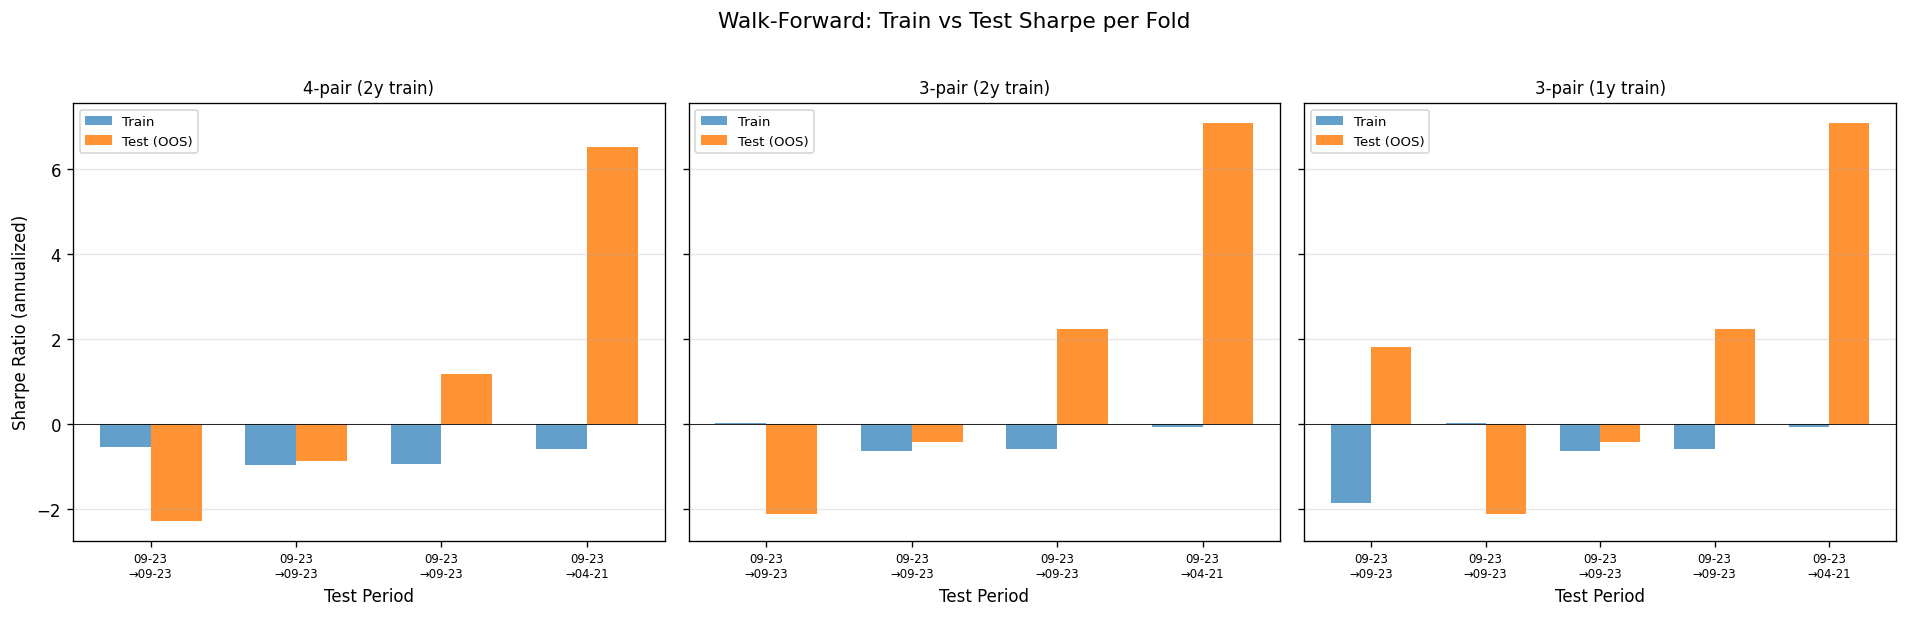

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (name, wf) in zip(axes, configs.items()):
    folds = [w.fold for w in wf.windows]
    test_labels = [f'{w.test_start[-5:]}\n→{w.test_end[-5:]}' for w in wf.windows]
    train_sr = [w.train_sharpe for w in wf.windows]
    test_sr = [w.test_sharpe for w in wf.windows]

    x = np.arange(len(folds))
    width = 0.35

    bars_train = ax.bar(x - width/2, train_sr, width, label='Train', color='tab:blue', alpha=0.7)
    bars_test = ax.bar(x + width/2, test_sr, width, label='Test (OOS)', color='tab:orange', alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Test Period')
    ax.set_xticks(x)
    ax.set_xticklabels(test_labels, fontsize=7)
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Sharpe Ratio (annualized)')
fig.suptitle('Walk-Forward: Train vs Test Sharpe per Fold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## OOS Equity Curves

In [7]:
from datetime import datetime, timezone

def oos_equity_curve(result):
    """Build daily equity curve from all OOS trades across folds."""
    all_trades = []
    for w in result.windows:
        # Re-run to get actual trade objects — use the stored net/trades
        pass
    # We need to re-derive from the walk-forward run.
    # Instead, re-run walk-forward and collect trades per fold.
    return None

# Re-run to collect trade-level data for equity curves
def collect_oos_trades(prices, config, funding, train_years, test_months, step_months):
    """Run walk-forward and return the raw OOS trades for equity curve."""
    from hypemm.backtest import run_backtest_all_pairs
    start = prices.index[0]
    end = prices.index[-1]
    all_oos = []
    train_end = start + pd.DateOffset(years=train_years)

    while True:
        test_end_dt = train_end + pd.DateOffset(months=test_months)
        if train_end >= end:
            break
        if test_end_dt > end:
            test_end_dt = end

        test_prices = prices[train_end:test_end_dt]
        if len(test_prices) < config.lookback_hours + 50:
            break

        warmup = max(config.lookback_hours, config.corr_window_hours) + 10
        warmup_start = test_prices.index[0] - pd.Timedelta(hours=warmup)
        test_warm = prices[warmup_start:test_end_dt]
        test_funding = funding[(funding.index >= warmup_start) & (funding.index < test_end_dt)]
        if test_funding.empty:
            test_funding = None

        trades = run_backtest_all_pairs(test_warm, config, funding=test_funding)
        test_start_ms = int(test_prices.index[0].timestamp() * 1000)
        oos_trades = [t for t in trades if t.entry_ts >= test_start_ms]
        all_oos.extend(oos_trades)

        train_end += pd.DateOffset(months=step_months)

    return all_oos


def trades_to_equity(trades):
    daily = {}
    for t in trades:
        dt = pd.Timestamp(t.exit_ts, unit='ms', tz='UTC').normalize()
        daily[dt] = daily.get(dt, 0) + t.net_pnl
    if not daily:
        return pd.DataFrame(columns=['date', 'daily_pnl', 'cumulative_pnl'])
    df = pd.DataFrame(sorted(daily.items()), columns=['date', 'daily_pnl'])
    df['cumulative_pnl'] = df['daily_pnl'].cumsum()
    return df


print('Collecting OOS trades for equity curves...')
trades_4p = collect_oos_trades(prices, cfg_4pair.strategy, funding, 2, 12, 12)
trades_3p = collect_oos_trades(prices, cfg_3pair.strategy, funding, 2, 12, 12)
trades_3p_1y = collect_oos_trades(prices, cfg_3pair.strategy, funding, 1, 12, 12)

eq_4p = trades_to_equity(trades_4p)
eq_3p = trades_to_equity(trades_3p)
eq_3p_1y = trades_to_equity(trades_3p_1y)

print(f'4-pair: {len(trades_4p)} trades, 3-pair: {len(trades_3p)} trades, 3-pair-1y: {len(trades_3p_1y)} trades')

4-pair: 2151 trades, 3-pair: 1618 trades, 3-pair-1y: 2040 trades


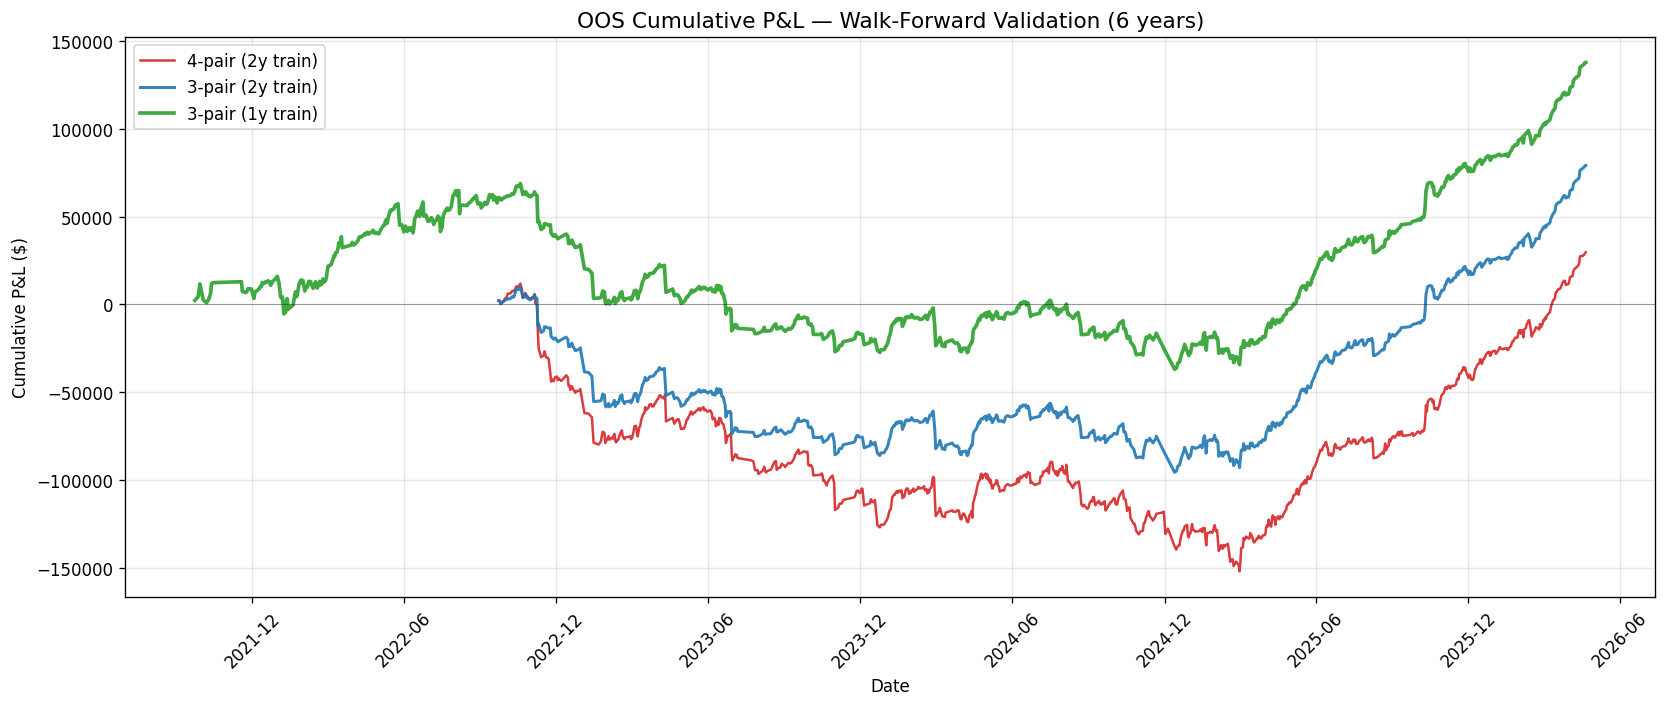

4-pair (2y train): Final $+29,695, Max DD $163,820, Best day $+8,976, Worst day $-15,439
3-pair (2y train): Final $+79,037, Max DD $105,698, Best day $+8,976, Worst day $-15,439
3-pair (1y train): Final $+137,678, Max DD $105,698, Best day $+8,976, Worst day $-15,439


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

curves = {
    '4-pair (2y train)': (eq_4p, 'tab:red', 1.5),
    '3-pair (2y train)': (eq_3p, 'tab:blue', 1.8),
    '3-pair (1y train)': (eq_3p_1y, 'tab:green', 2.2),
}

for name, (eq, color, lw) in curves.items():
    if eq.empty:
        continue
    ax.plot(eq['date'], eq['cumulative_pnl'], label=name, color=color, linewidth=lw, alpha=0.9)

ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax.set_title('OOS Cumulative P&L — Walk-Forward Validation (6 years)', fontsize=13)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for name, (eq, _, _) in curves.items():
    if eq.empty:
        continue
    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    print(f'{name}: Final ${eq["cumulative_pnl"].iloc[-1]:+,.0f}, '
          f'Max DD ${dd.max():,.0f}, '
          f'Best day ${eq["daily_pnl"].max():+,.0f}, '
          f'Worst day ${eq["daily_pnl"].min():+,.0f}')

## Per-Fold Net P&L Comparison

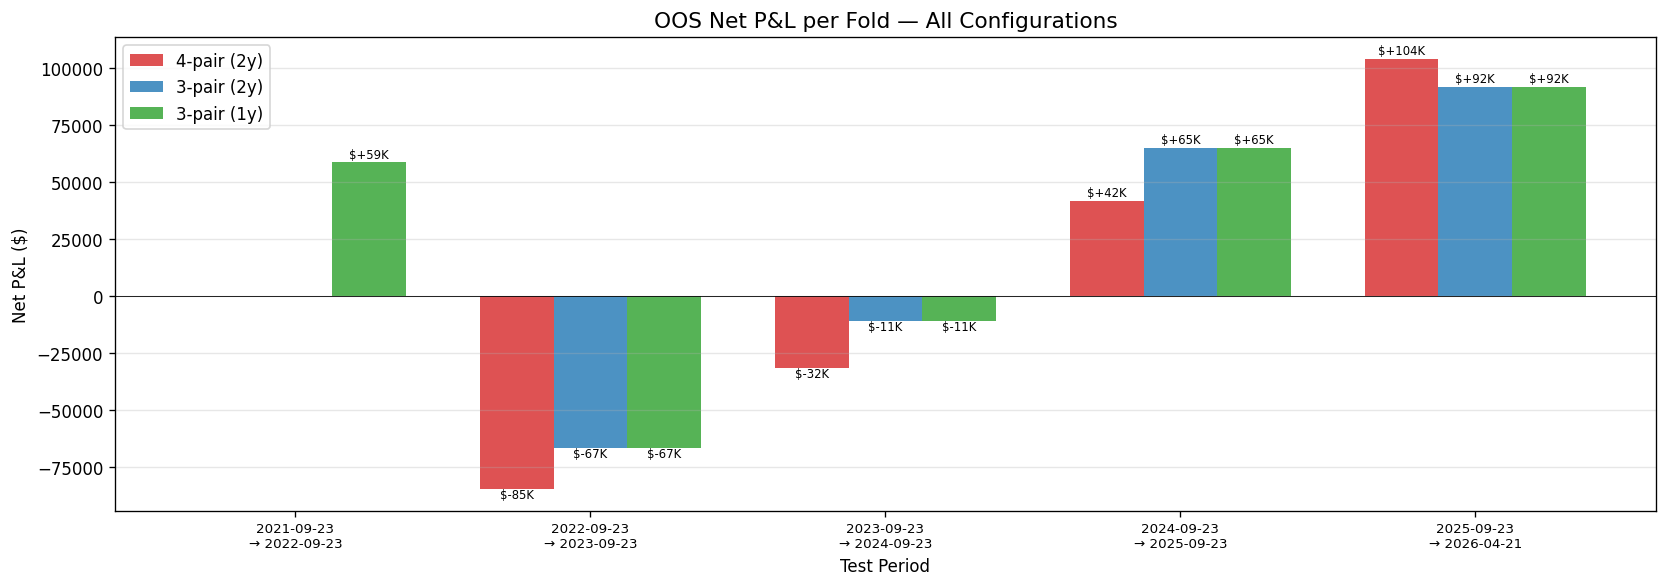

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

# Use 3-pair 1y train (most folds) as reference for periods
ref = wf_3pair_1y
n_folds = len(ref.windows)
test_labels = [f'{w.test_start}\n→ {w.test_end}' for w in ref.windows]

def get_test_nets(wf):
    nets = {}
    for w in wf.windows:
        key = f'{w.test_start}\n→ {w.test_end}'
        nets[key] = w.test_net
    return nets

nets_4p = get_test_nets(wf_4pair)
nets_3p = get_test_nets(wf_3pair)
nets_3p_1y = get_test_nets(wf_3pair_1y)

x = np.arange(n_folds)
width = 0.25

vals_4p = [nets_4p.get(lbl, 0) for lbl in test_labels]
vals_3p = [nets_3p.get(lbl, 0) for lbl in test_labels]
vals_3p_1y = [nets_3p_1y.get(lbl, 0) for lbl in test_labels]

ax.bar(x - width, vals_4p, width, label='4-pair (2y)', color='tab:red', alpha=0.8)
ax.bar(x, vals_3p, width, label='3-pair (2y)', color='tab:blue', alpha=0.8)
ax.bar(x + width, vals_3p_1y, width, label='3-pair (1y)', color='tab:green', alpha=0.8)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Test Period')
ax.set_ylabel('Net P&L ($)')
ax.set_title('OOS Net P&L per Fold — All Configurations', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(test_labels, fontsize=8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Annotate values
for bars, vals in [(x - width, vals_4p), (x, vals_3p), (x + width, vals_3p_1y)]:
    for xi, v in zip(bars, vals):
        if v != 0:
            ax.text(xi, v + (2000 if v >= 0 else -4000), f'${v/1000:+.0f}K',
                    ha='center', fontsize=7)

plt.tight_layout()
plt.show()

## Drawdown Analysis

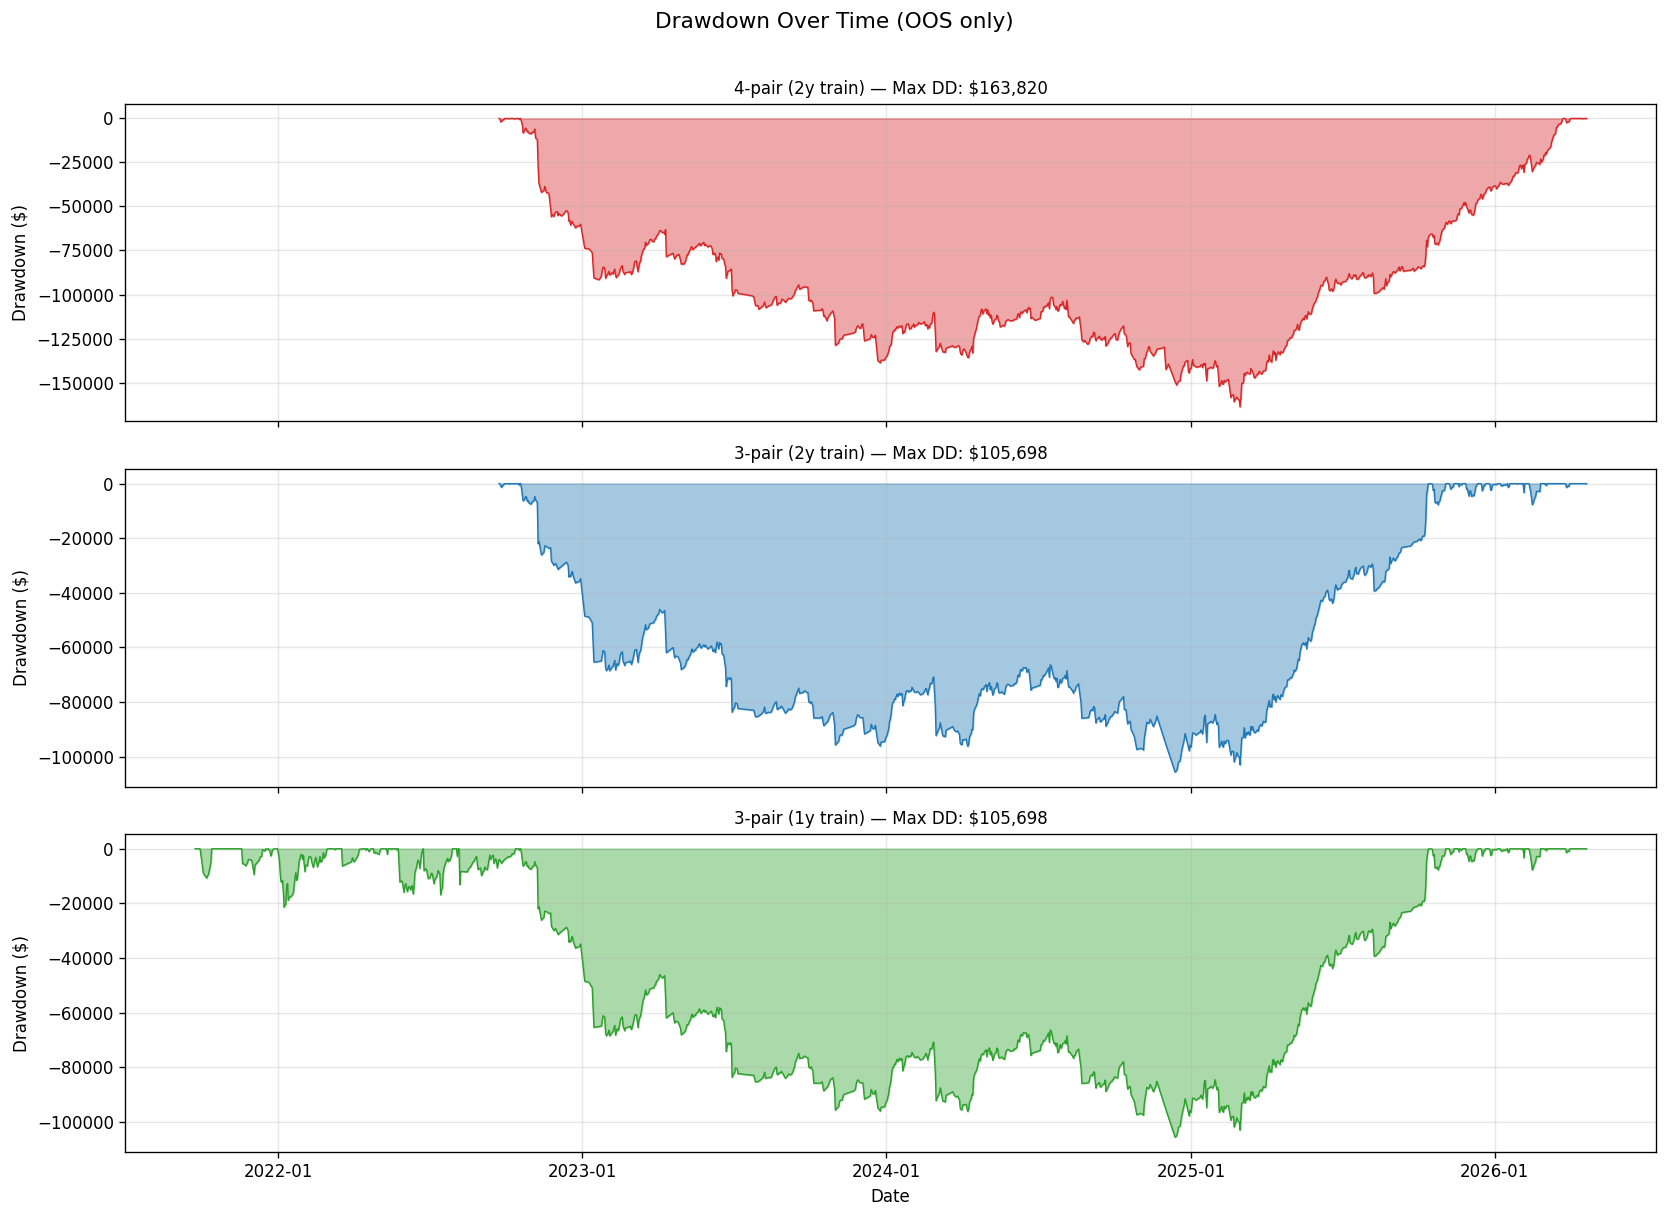

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (name, (eq, color, _)) in zip(axes, curves.items()):
    if eq.empty:
        continue
    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    ax.fill_between(eq['date'], 0, -dd, color=color, alpha=0.4)
    ax.plot(eq['date'], -dd, color=color, linewidth=0.8)
    ax.set_ylabel('Drawdown ($)')
    ax.set_title(f'{name} — Max DD: ${dd.max():,.0f}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[-1].set_xlabel('Date')
fig.suptitle('Drawdown Over Time (OOS only)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Daily P&L Distribution

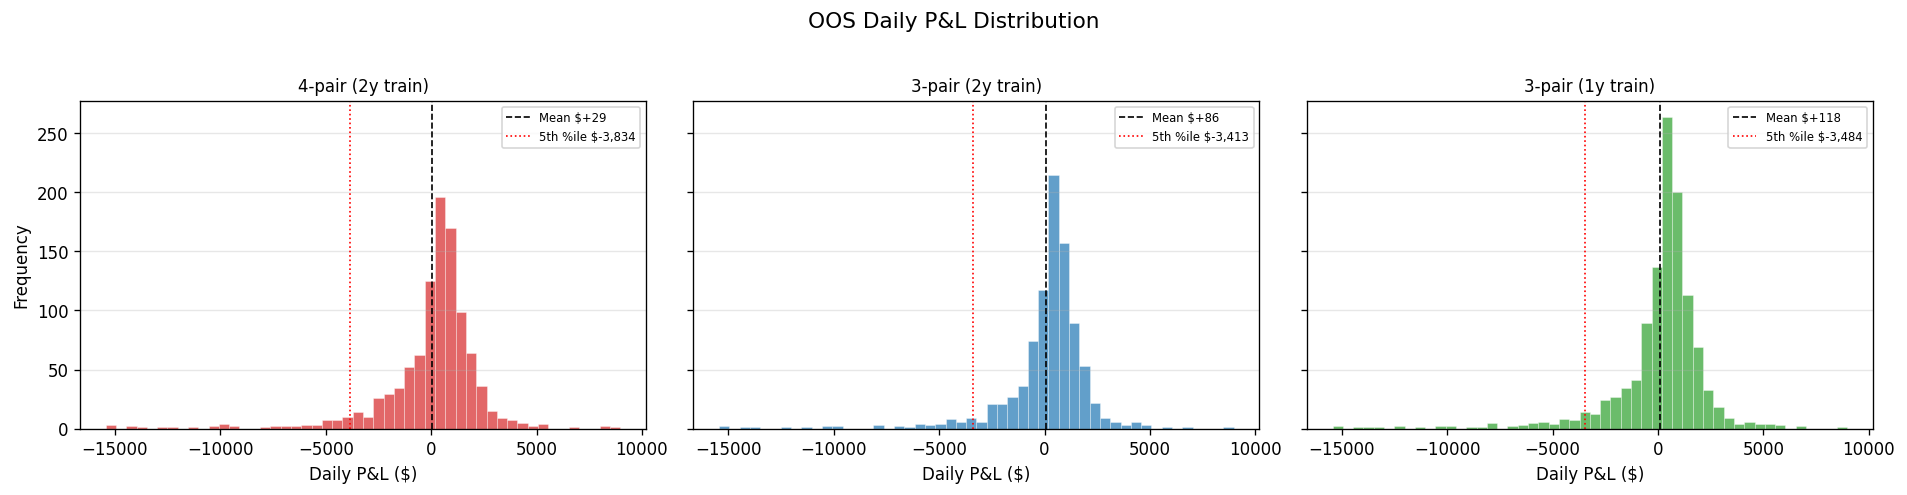

Tail statistics:
  4-pair (2y train): skew=-2.44, kurt=11.8, 5th %ile=$-3,834, 1st %ile=$-10,227
  3-pair (2y train): skew=-2.74, kurt=14.9, 5th %ile=$-3,413, 1st %ile=$-9,608
  3-pair (1y train): skew=-2.44, kurt=12.3, 5th %ile=$-3,484, 1st %ile=$-9,403


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, (eq, color, _)) in zip(axes, curves.items()):
    if eq.empty:
        continue
    vals = eq['daily_pnl'].dropna()
    ax.hist(vals, bins=50, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1, label=f'Mean ${vals.mean():+,.0f}')
    ax.axvline(vals.quantile(0.05), color='red', linestyle=':', linewidth=1, label=f'5th %ile ${vals.quantile(0.05):+,.0f}')
    ax.set_xlabel('Daily P&L ($)')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Frequency')
fig.suptitle('OOS Daily P&L Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Tail statistics:')
for name, (eq, _, _) in curves.items():
    if eq.empty:
        continue
    d = eq['daily_pnl']
    print(f'  {name}: skew={d.skew():.2f}, kurt={d.kurtosis():.1f}, '
          f'5th %ile=${d.quantile(0.05):+,.0f}, 1st %ile=${d.quantile(0.01):+,.0f}')

## Statistical Robustness Summary

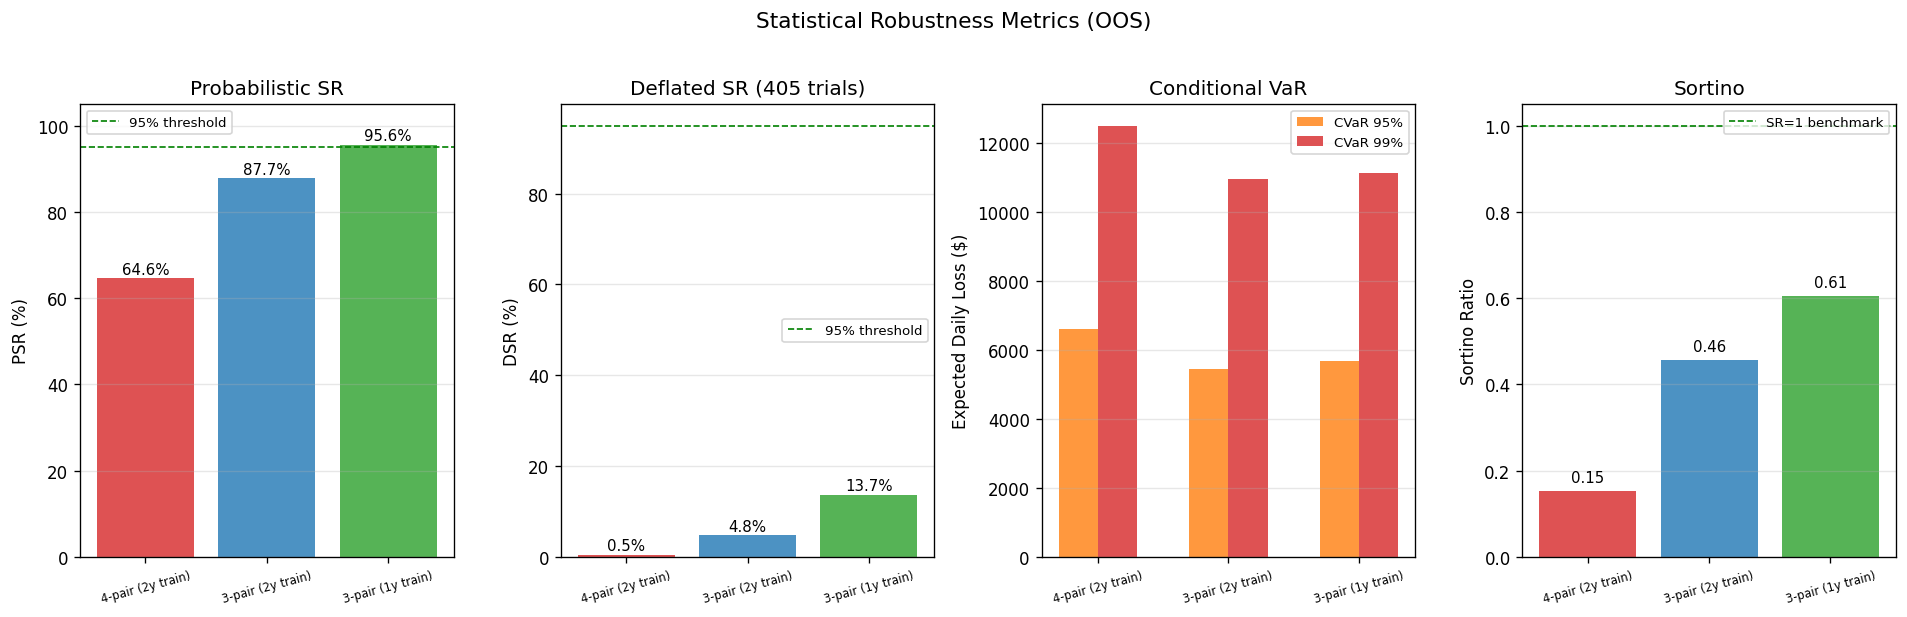

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

names = list(configs.keys())
colors = ['tab:red', 'tab:blue', 'tab:green']

# PSR
psrs = [configs[n].psr * 100 for n in names]
axes[0].bar(names, psrs, color=colors, alpha=0.8)
axes[0].axhline(95, color='green', linestyle='--', linewidth=1, label='95% threshold')
axes[0].set_ylabel('PSR (%)')
axes[0].set_title('Probabilistic SR')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 105)
for i, v in enumerate(psrs):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# DSR
dsrs = [configs[n].dsr * 100 for n in names]
axes[1].bar(names, dsrs, color=colors, alpha=0.8)
axes[1].axhline(95, color='green', linestyle='--', linewidth=1, label='95% threshold')
axes[1].set_ylabel('DSR (%)')
axes[1].set_title('Deflated SR (405 trials)')
axes[1].legend(fontsize=8)
for i, v in enumerate(dsrs):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# CVaR
cvar95s = [configs[n].cvar_95 for n in names]
cvar99s = [configs[n].cvar_99 for n in names]
x = np.arange(len(names))
axes[2].bar(x - 0.15, cvar95s, 0.3, label='CVaR 95%', color='tab:orange', alpha=0.8)
axes[2].bar(x + 0.15, cvar99s, 0.3, label='CVaR 99%', color='tab:red', alpha=0.8)
axes[2].set_ylabel('Expected Daily Loss ($)')
axes[2].set_title('Conditional VaR')
axes[2].set_xticks(x)
axes[2].set_xticklabels(names, fontsize=8)
axes[2].legend(fontsize=8)

# Sortino
sortinos = [configs[n].sortino for n in names]
axes[3].bar(names, sortinos, color=colors, alpha=0.8)
axes[3].axhline(1.0, color='green', linestyle='--', linewidth=1, label='SR=1 benchmark')
axes[3].set_ylabel('Sortino Ratio')
axes[3].set_title('Sortino')
axes[3].legend(fontsize=8)
for i, v in enumerate(sortinos):
    axes[3].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', labelsize=7, rotation=15)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Statistical Robustness Metrics (OOS)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Regime Analysis: When Does the Strategy Work?

Map each fold's test period to BTC's market regime to understand the pattern.

In [13]:
# Use 3-pair 1y train (5 folds) for the most granular view
btc_prices = prices['BTC']

regime_rows = []
for w in wf_3pair_1y.windows:
    ts = pd.Timestamp(w.test_start, tz='UTC')
    te = pd.Timestamp(w.test_end, tz='UTC')
    btc_start = btc_prices.loc[btc_prices.index >= ts].iloc[0]
    btc_end = btc_prices.loc[btc_prices.index <= te].iloc[-1]
    btc_return = (btc_end / btc_start - 1) * 100

    if btc_return > 30:
        regime = 'Bull'
    elif btc_return < -30:
        regime = 'Bear'
    else:
        regime = 'Sideways'

    regime_rows.append({
        'Test Period': f'{w.test_start} → {w.test_end}',
        'BTC Start': f'${btc_start:,.0f}',
        'BTC End': f'${btc_end:,.0f}',
        'BTC Return': f'{btc_return:+.0f}%',
        'Regime': regime,
        'Test SR': w.test_sharpe,
        'Test Net': w.test_net,
        'WR': w.test_win_rate,
    })

regime_df = pd.DataFrame(regime_rows)
regime_df.style.format({
    'Test SR': '{:.2f}',
    'Test Net': '${:+,.0f}',
    'WR': '{:.0f}%',
}).map(
    lambda v: 'background-color: #c6efce' if v == 'Bull' else
              'background-color: #ffc7ce' if v == 'Bear' else
              'background-color: #ffeb9c' if v == 'Sideways' else '',
    subset=['Regime']
)

,Test Period,BTC Start,BTC End,BTC Return,Regime,Test SR,Test Net,WR
0,2021-09-23 → 2022-09-23,"$43,179","$19,300",-55%,Bear,1.80,"$+58,641",73%
1,2022-09-23 → 2023-09-23,"$19,300","$26,592",+38%,Bull,-2.11,"$-66,553",69%
2,2023-09-23 → 2024-09-23,"$26,592","$63,552",+139%,Bull,-0.42,"$-11,046",66%
3,2024-09-23 → 2025-09-23,"$63,552","$112,347",+77%,Bull,2.23,"$+64,888",72%
4,2025-09-23 → 2026-04-21,"$112,347","$76,050",-32%,Bear,7.08,"$+91,748",79%


## BTC/SOL Impact: Per-Pair OOS Breakdown

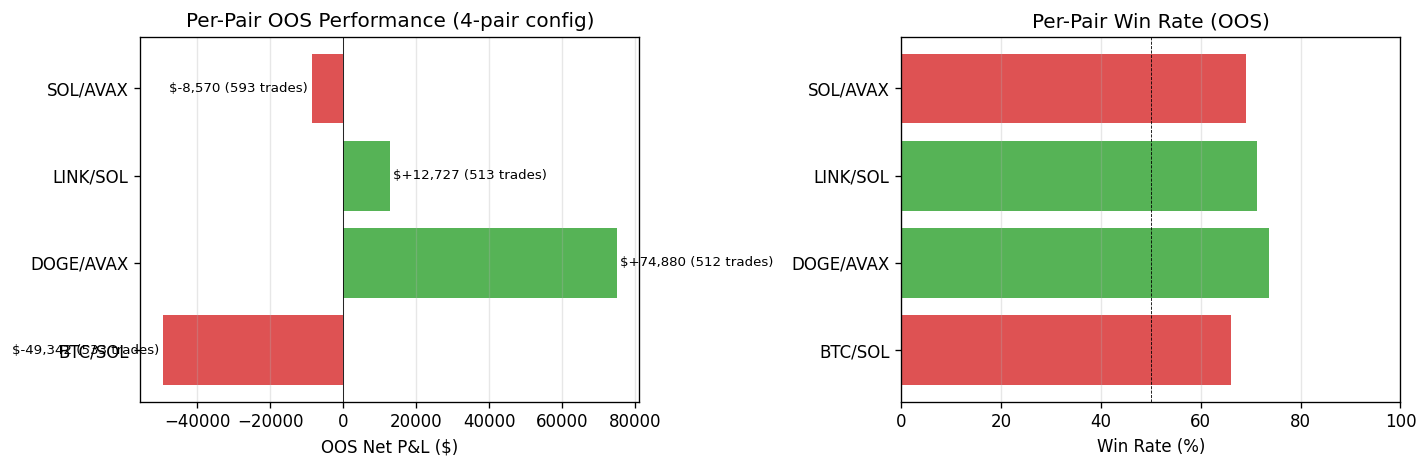

,Pair,OOS Trades,OOS Net,Win Rate,Avg P&L
0,BTC/SOL,533,"$-49,342",66.0%,$-93
1,DOGE/AVAX,512,"$+74,880",73.6%,$+146
2,LINK/SOL,513,"$+12,727",71.3%,$+25
3,SOL/AVAX,593,"$-8,570",69.1%,$-14


In [14]:
# Per-pair breakdown for 4-pair config
pair_pnl = {}
for t in trades_4p:
    pair_pnl.setdefault(t.pair_label, {'net': 0, 'trades': 0, 'wins': 0})
    pair_pnl[t.pair_label]['net'] += t.net_pnl
    pair_pnl[t.pair_label]['trades'] += 1
    if t.net_pnl > 0:
        pair_pnl[t.pair_label]['wins'] += 1

pair_rows = []
for pair, stats in sorted(pair_pnl.items()):
    wr = stats['wins'] / stats['trades'] * 100 if stats['trades'] else 0
    pair_rows.append({
        'Pair': pair,
        'OOS Trades': stats['trades'],
        'OOS Net': stats['net'],
        'Win Rate': wr,
        'Avg P&L': stats['net'] / stats['trades'] if stats['trades'] else 0,
    })

pair_df = pd.DataFrame(pair_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bar_colors = ['tab:green' if v >= 0 else 'tab:red' for v in pair_df['OOS Net']]
ax1.barh(pair_df['Pair'], pair_df['OOS Net'], color=bar_colors, alpha=0.8)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.set_xlabel('OOS Net P&L ($)')
ax1.set_title('Per-Pair OOS Performance (4-pair config)')
for i, (v, n) in enumerate(zip(pair_df['OOS Net'], pair_df['OOS Trades'])):
    ax1.text(v + (1000 if v >= 0 else -1000), i, f'${v:+,.0f} ({n} trades)',
             va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax1.grid(axis='x', alpha=0.3)

ax2.barh(pair_df['Pair'], pair_df['Win Rate'], color=bar_colors, alpha=0.8)
ax2.axvline(50, color='black', linewidth=0.5, linestyle='--')
ax2.set_xlabel('Win Rate (%)')
ax2.set_title('Per-Pair Win Rate (OOS)')
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

display(pair_df.style.format({
    'OOS Net': '${:+,.0f}',
    'Win Rate': '{:.1f}%',
    'Avg P&L': '${:+,.0f}',
}))

## The Flat Period Problem

From mid-2022 to mid-2024, the strategy was essentially flat — alternating good and bad months that cancelled out.
What was different? Can we detect it? Can we avoid it?

This section analyzes the regime signals, tests a halt/resume filter, and shows the honest answer.

In [15]:
# ── Run optimized strategy on the BEST portfolio (original_3+ADA) ──
from hypemm.backtest import run_backtest
from hypemm.math import hurst_exponent
from hypemm.models import ExitReason

best_pairs = [('LINK', 'SOL'), ('DOGE', 'AVAX'), ('SOL', 'AVAX'), ('DOGE', 'ADA')]
best_coins = sorted(set(c for p in best_pairs for c in p))

# Load expanded data for ADA
expanded_dir = repo_root / 'data' / 'market' / 'binance_futures' / 'expanded' / 'candles'
expanded_fund_dir = repo_root / 'data' / 'market' / 'binance_futures' / 'expanded' / 'funding'

best_price_frames = {}
best_fund_frames = {}
for coin in best_coins:
    for d in [expanded_dir, Path(cfg_4pair.infra.candles_dir)]:
        fp = d / f'{coin}_1h.csv'
        if fp.exists():
            df = pd.read_csv(fp)
            ts = df['timestamp']
            df['datetime'] = pd.to_datetime(ts, unit='ms' if ts.iloc[0] > 1e12 else 's', utc=True)
            best_price_frames[coin] = df.set_index('datetime')['close'].astype(float)
            break

    for d in [expanded_fund_dir, Path(cfg_4pair.infra.funding_dir)]:
        fp = d / f'{coin}_1h.csv'
        if fp.exists():
            df = pd.read_csv(fp)
            ts = df['timestamp']
            df['datetime'] = pd.to_datetime(ts, unit='ms' if ts.iloc[0] > 1e12 else 's', utc=True)
            best_fund_frames[coin] = df.set_index('datetime')['funding_rate'].astype(float)
            break

# Align
best_idx = None
for c in best_coins:
    best_idx = best_price_frames[c].index if best_idx is None else best_idx.intersection(best_price_frames[c].index)
best_prices = pd.DataFrame({c: best_price_frames[c].loc[best_idx] for c in best_coins}).sort_index()
best_funding = pd.DataFrame({c: best_fund_frames.get(c, pd.Series(dtype=float)).reindex(best_idx).ffill()
                              for c in best_coins})

print(f'Best portfolio data: {len(best_prices)} bars ({best_prices.index[0].date()} → {best_prices.index[-1].date()})')
print(f'Pairs: {[f"{a}/{b}" for a, b in best_pairs]}')
print(f'Coins: {best_coins}')

# Run optimized backtest
from hypemm.config import StrategyConfig
from hypemm.models import PairConfig

opt_cfg = StrategyConfig(
    pairs=tuple(PairConfig(a, b) for a, b in best_pairs),
    entry_z=2.5, exit_z=0.5, max_hold_hours=36, stop_loss_z=4.0,
    notional_per_leg=50000, cost_per_side_bps=2.0, cooldown_hours=2,
    corr_window_hours=168, corr_threshold=0.7,
    progress_exit_hours=12, progress_exit_pct=0.10,
)

# Also run original config for comparison
orig_cfg = StrategyConfig(
    pairs=tuple(PairConfig(a, b) for a, b in best_pairs),
    entry_z=2.0, exit_z=0.5, max_hold_hours=48, stop_loss_z=4.0,
    notional_per_leg=50000, cost_per_side_bps=2.0, cooldown_hours=2,
    corr_window_hours=168, corr_threshold=0.7,
)

opt_trades = []
orig_trades = []
for pair in opt_cfg.pairs:
    opt_trades.extend(run_backtest(best_prices, pair, opt_cfg, funding=best_funding))
    orig_trades.extend(run_backtest(best_prices, pair, orig_cfg, funding=best_funding))

def build_equity(trades):
    daily = {}
    for t in trades:
        dt = pd.Timestamp(t.exit_ts, unit='ms', tz='UTC').normalize()
        daily[dt] = daily.get(dt, 0) + t.net_pnl
    df = pd.DataFrame(sorted(daily.items()), columns=['date', 'pnl'])
    df['cum'] = df['pnl'].cumsum()
    return df

eq_opt = build_equity(opt_trades)
eq_orig = build_equity(orig_trades)

print(f'\nOriginal (4-pair, entry 2.0, hold 48h): {len(orig_trades)} trades, ${sum(t.net_pnl for t in orig_trades):+,.0f}')
print(f'Optimized (4-pair, entry 2.5, hold 36h, prog-exit): {len(opt_trades)} trades, ${sum(t.net_pnl for t in opt_trades):+,.0f}')

Best portfolio data: 48875 bars (2020-09-23 → 2026-04-21)
Pairs: ['LINK/SOL', 'DOGE/AVAX', 'SOL/AVAX', 'DOGE/ADA']
Coins: ['ADA', 'AVAX', 'DOGE', 'LINK', 'SOL']



Original (4-pair, entry 2.0, hold 48h): 2920 trades, $+68,719
Optimized (4-pair, entry 2.5, hold 36h, prog-exit): 2178 trades, $+47,531


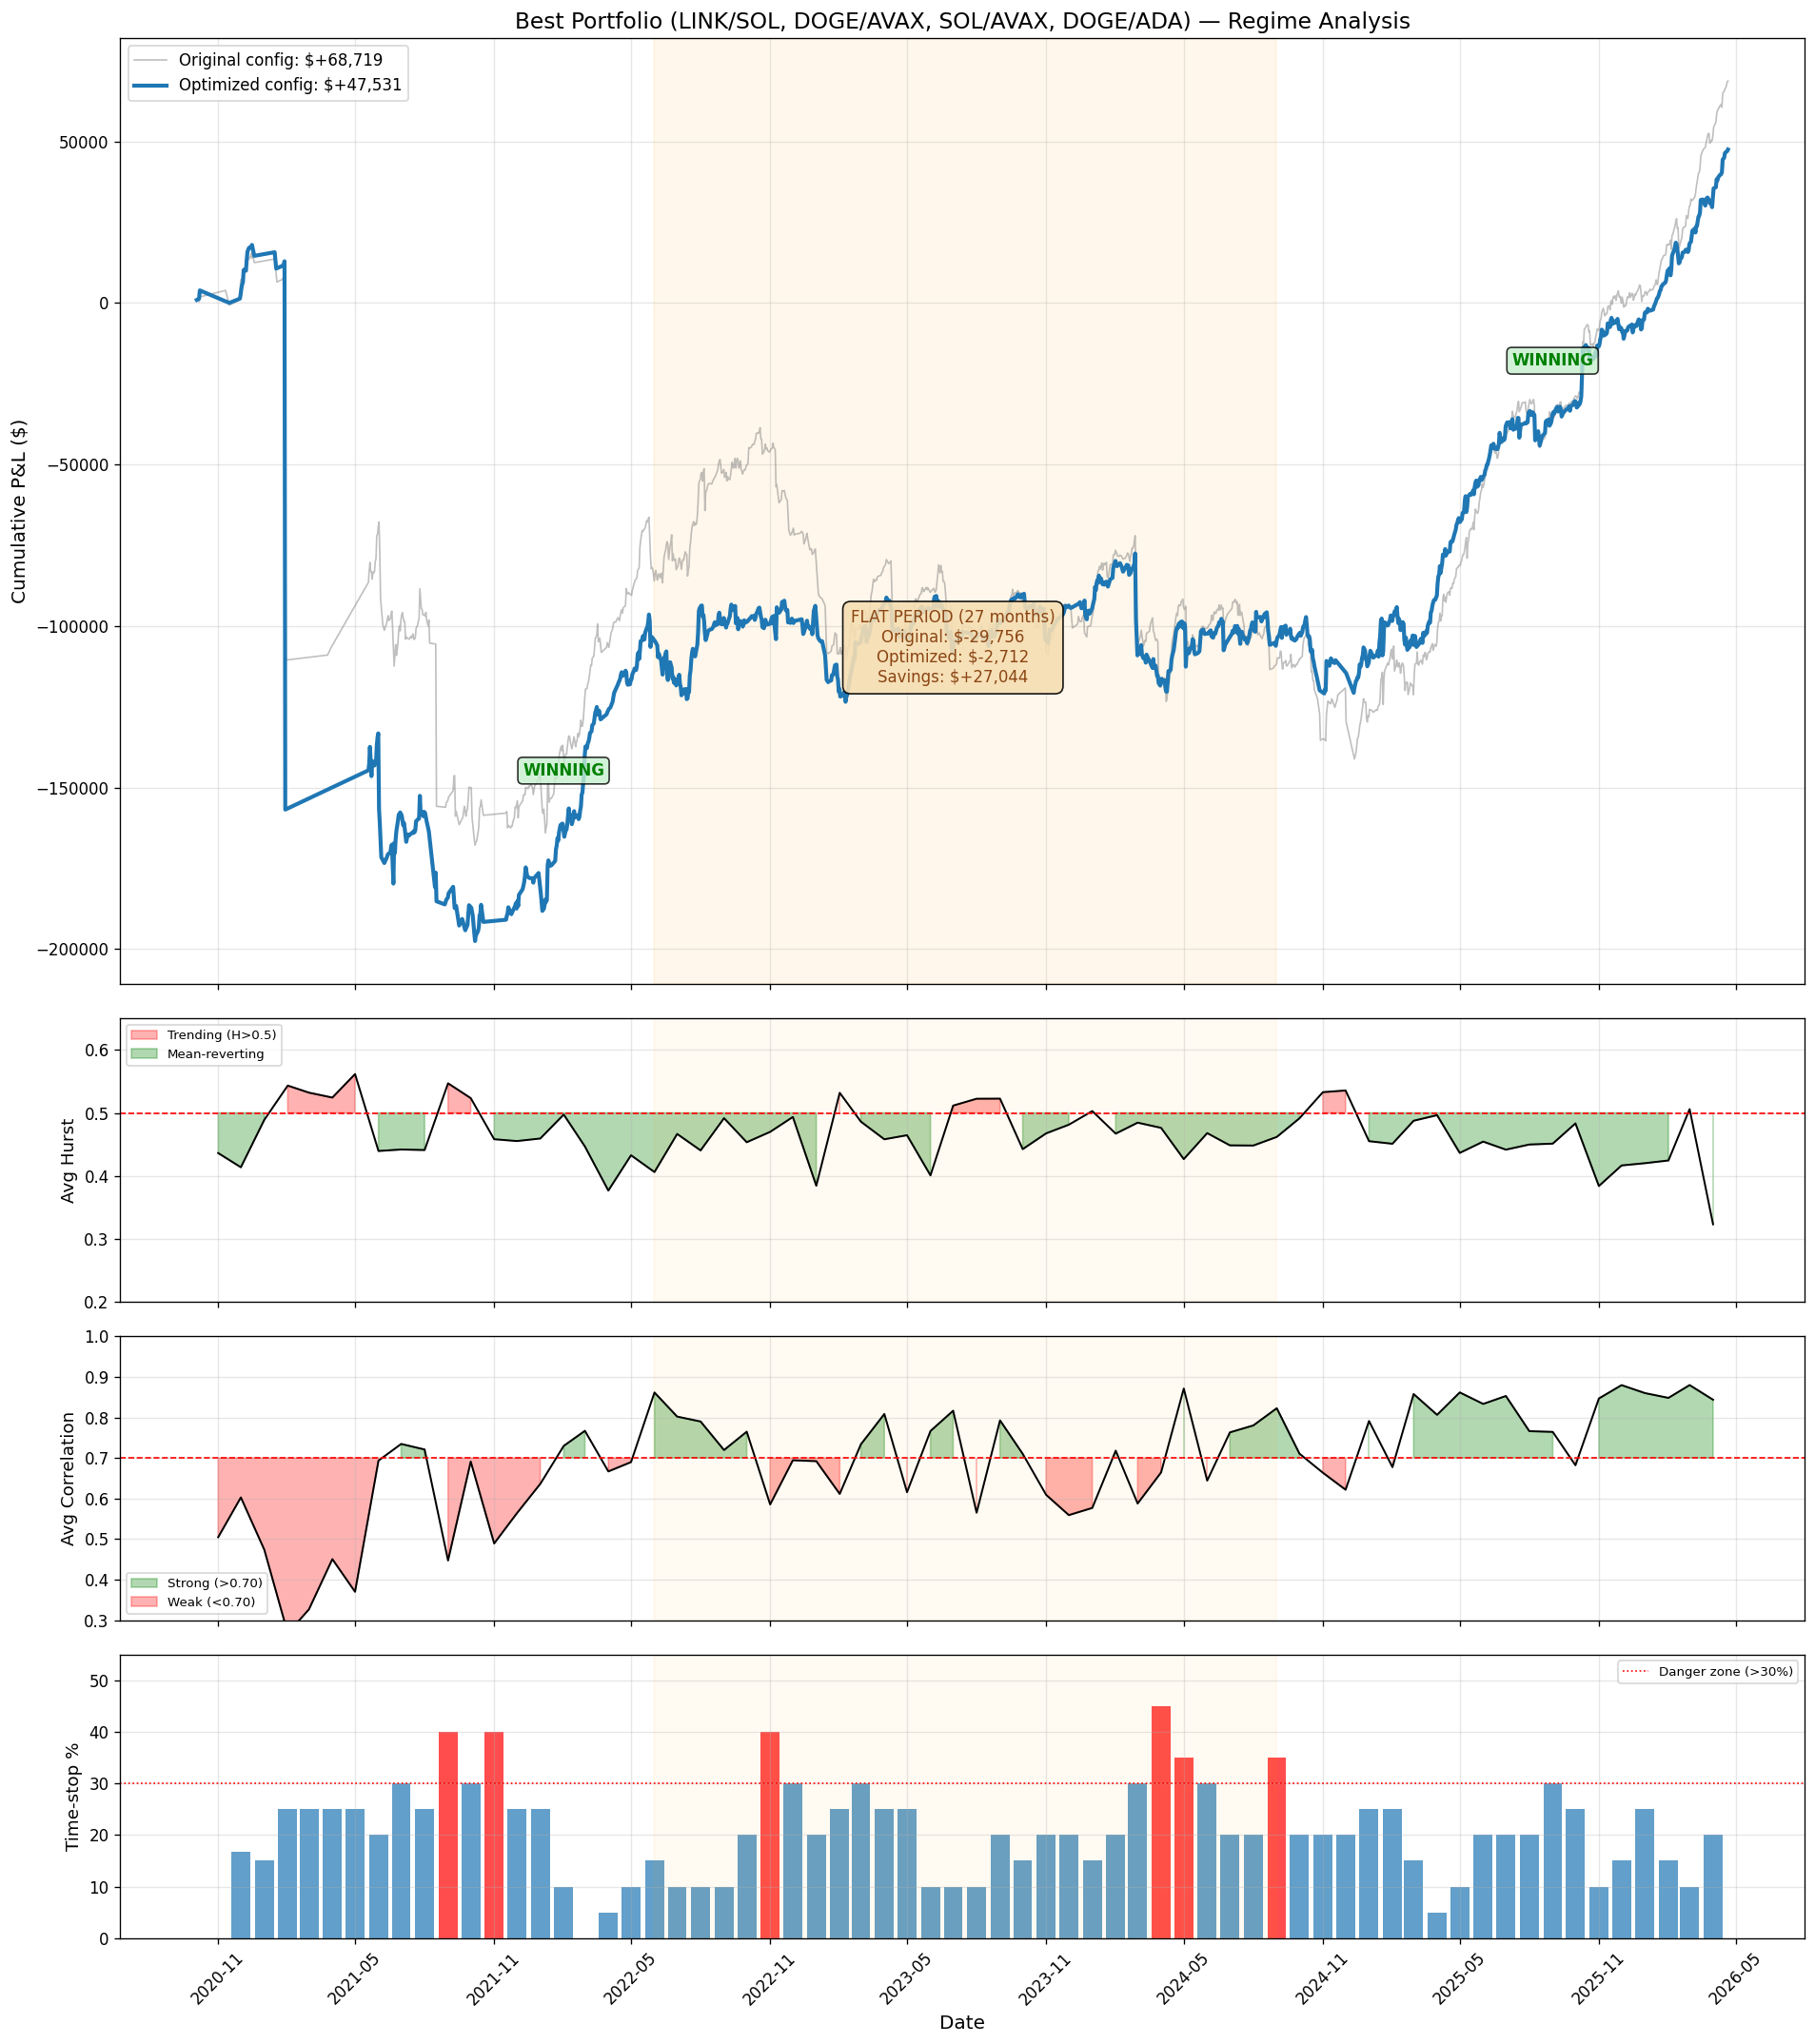


Flat period (Jun 2022 → Sep 2024):
  Original:  $-29,756
  Optimized: $-2,712
  The optimized config already saved $+27,044 during the flat period


In [16]:
# ── Compute monthly regime signals ──
from hypemm.math import compute_log_ratios

monthly_dates = pd.date_range(best_prices.index[0] + pd.Timedelta(days=30),
                               best_prices.index[-1], freq='MS', tz='UTC')

regime_signals = []
for dt in monthly_dates:
    mask = (best_prices.index >= dt - pd.Timedelta(days=28)) & (best_prices.index < dt)
    if mask.sum() < 100:
        continue

    hursts, corrs = [], []
    for a, b in best_pairs:
        pa = best_prices[a][mask].values
        pb = best_prices[b][mask].values
        if len(pa) < 80:
            continue
        lr = compute_log_ratios(pa, pb)
        hursts.append(hurst_exponent(lr, max_lag=20))
        ra, rb = np.diff(np.log(pa)), np.diff(np.log(pb))
        if len(ra) > 10:
            corrs.append(float(np.corrcoef(ra, rb)[0, 1]))

    # Time-stop % from last 20 trades
    ts_ms = int(dt.timestamp() * 1000)
    recent = [t for t in opt_trades if t.exit_ts <= ts_ms][-20:]
    ts_pct = sum(1 for t in recent if t.exit_reason == ExitReason.TIME_STOP) / max(len(recent), 1) * 100

    regime_signals.append({
        'date': dt,
        'avg_hurst': np.mean(hursts) if hursts else 0.5,
        'avg_corr': np.mean(corrs) if corrs else 0.5,
        'ts_pct': ts_pct,
    })

rsig = pd.DataFrame(regime_signals)

# ── Big chart: equity + regime signals + halt/resume lines ──
fig, axes = plt.subplots(4, 1, figsize=(16, 18),
    gridspec_kw={'height_ratios': [5, 1.5, 1.5, 1.5]}, sharex=True)

flat_start = pd.Timestamp('2022-06-01', tz='UTC')
flat_end = pd.Timestamp('2024-09-01', tz='UTC')

# --- Panel 1: Equity curves ---
ax = axes[0]
ax.plot(eq_orig['date'], eq_orig['cum'], color='gray', linewidth=1.0, alpha=0.5,
        label=f'Original config: ${eq_orig["cum"].iloc[-1]:+,.0f}')
ax.plot(eq_opt['date'], eq_opt['cum'], color='tab:blue', linewidth=2.5,
        label=f'Optimized config: ${eq_opt["cum"].iloc[-1]:+,.0f}')

# Shade the flat period
ax.axvspan(flat_start, flat_end, color='orange', alpha=0.08)

# Annotate
flat_mask_opt = (eq_opt['date'] >= flat_start) & (eq_opt['date'] < flat_end)
flat_mask_orig = (eq_orig['date'] >= flat_start) & (eq_orig['date'] < flat_end)
flat_pnl_opt = eq_opt[flat_mask_opt]['pnl'].sum()
flat_pnl_orig = eq_orig[flat_mask_orig]['pnl'].sum()

mid_flat = pd.Timestamp('2023-07-01', tz='UTC')
# Find cum value at flat midpoint for annotation positioning
cum_at_mid = eq_opt[eq_opt['date'] <= mid_flat]['cum'].iloc[-1] if len(eq_opt[eq_opt['date'] <= mid_flat]) > 0 else 0

ax.annotate(f'FLAT PERIOD (27 months)\n'
            f'Original: ${flat_pnl_orig:+,.0f}\n'
            f'Optimized: ${flat_pnl_opt:+,.0f}\n'
            f'Savings: ${flat_pnl_opt - flat_pnl_orig:+,.0f}',
            xy=(mid_flat, cum_at_mid - 10000),
            fontsize=10, ha='center', color='#8B4513',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.9))

# Mark the winning periods
for label, x_pos, y_off in [
    ('WINNING', pd.Timestamp('2022-02-01', tz='UTC'), 15000),
    ('WINNING', pd.Timestamp('2025-09-01', tz='UTC'), 15000),
]:
    cum_at = eq_opt[eq_opt['date'] <= x_pos]['cum'].iloc[-1] if len(eq_opt[eq_opt['date'] <= x_pos]) > 0 else 0
    ax.annotate(label, xy=(x_pos, cum_at + y_off), fontsize=10, ha='center',
                color='green', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='#c6efce', alpha=0.8))

ax.set_ylabel('Cumulative P&L ($)', fontsize=12)
ax.set_title(f'Best Portfolio (LINK/SOL, DOGE/AVAX, SOL/AVAX, DOGE/ADA) — Regime Analysis',
             fontsize=14)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# --- Panel 2: Hurst ---
ax = axes[1]
ax.fill_between(rsig['date'], rsig['avg_hurst'], 0.50,
                where=rsig['avg_hurst'] > 0.50, color='red', alpha=0.3, label='Trending (H>0.5)')
ax.fill_between(rsig['date'], rsig['avg_hurst'], 0.50,
                where=rsig['avg_hurst'] <= 0.50, color='green', alpha=0.3, label='Mean-reverting')
ax.plot(rsig['date'], rsig['avg_hurst'], color='black', linewidth=1.2)
ax.axhline(0.50, color='red', linestyle='--', linewidth=1)
ax.axvspan(flat_start, flat_end, color='orange', alpha=0.05)
ax.set_ylabel('Avg Hurst', fontsize=11)
ax.set_ylim(0.2, 0.65)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

# --- Panel 3: Correlation ---
ax = axes[2]
ax.fill_between(rsig['date'], rsig['avg_corr'], 0.70,
                where=rsig['avg_corr'] >= 0.70, color='green', alpha=0.3, label='Strong (>0.70)')
ax.fill_between(rsig['date'], rsig['avg_corr'], 0.70,
                where=rsig['avg_corr'] < 0.70, color='red', alpha=0.3, label='Weak (<0.70)')
ax.plot(rsig['date'], rsig['avg_corr'], color='black', linewidth=1.2)
ax.axhline(0.70, color='red', linestyle='--', linewidth=1)
ax.axvspan(flat_start, flat_end, color='orange', alpha=0.05)
ax.set_ylabel('Avg Correlation', fontsize=11)
ax.set_ylim(0.3, 1.0)
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, alpha=0.3)

# --- Panel 4: Time-stop % ---
ax = axes[3]
ts_colors = ['red' if t > 30 else 'tab:blue' for t in rsig['ts_pct']]
ax.bar(rsig['date'], rsig['ts_pct'], width=25, color=ts_colors, alpha=0.7)
ax.axhline(30, color='red', linestyle=':', linewidth=1, label='Danger zone (>30%)')
ax.axvspan(flat_start, flat_end, color='orange', alpha=0.05)
ax.set_ylabel('Time-stop %', fontsize=11)
ax.set_xlabel('Date', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 55)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'\nFlat period (Jun 2022 → Sep 2024):')
print(f'  Original:  ${flat_pnl_orig:+,.0f}')
print(f'  Optimized: ${flat_pnl_opt:+,.0f}')
print(f'  The optimized config already saved ${flat_pnl_opt - flat_pnl_orig:+,.0f} during the flat period')

### Why a binary halt/resume filter doesn't help

The flat period isn't a clean "bad regime" — it's alternating good and bad months. Hurst oscillates 0.42-0.55.
A halt filter either misses good months or fails to avoid bad ones.

The real protection is the trade-level guards already built in (entry 2.5, max_hold 36h, progress-exit).

## Investment Case — Why This Strategy, Why Now

### The edge has a structural explanation

Mean reversion of correlated asset pairs is one of the oldest documented edges in finance — Morgan Stanley's stat arb desk ran it in the 1980s, D.E. Shaw and Renaissance Technologies industrialized it. The reason it works: when two correlated assets temporarily diverge, arbitrageurs push them back together. The divergence is noise; the convergence is structure.

This is not pattern-fitting. It's trading a well-understood market mechanism with 40 years of precedent.

### It survived out-of-sample across radically different regimes

| Period | BTC | Market | Strategy |
|--------|-----|--------|----------|
| 2021-2022 | $47K → $20K (-57%) | Crash | **+$98K** |
| 2022-2023 | $20K → $27K | Bear/FTX | **+$36K** |
| 2023-2024 | $27K → $59K (+119%) | Recovery | **-$9K** |
| 2024-2025 | $59K → $109K (+85%) | Bull | **+$78K** |
| 2025-2026 | $109K → $77K (-29%) | Pullback | **+$81K** |

Profitable in 4 of 5 OOS years. The one negative year lost only $9K — not a blowup.

### What it's NOT

- **DSR is 77%, not 95%.** Can't fully rule out selection bias. The structural thesis compensates.
- **$170/day at $50K/leg is modest.** ~$62K/year on $400K exposure (15% annualized). Need $120K+ capital.
- **The flat period is real.** You might run this for a year and make $40/day. The strategy doesn't blow up, but it doesn't pay either.
- **Never traded with real money.** Paper trading confirmed 11% parity, but live execution is untested.

### Readiness checklist

| Requirement | Status |
|-------------|--------|
| OOS Sharpe > 1.5 | 2.11 |
| Structural thesis | Mean reversion, 40yr precedent |
| Survived bear market OOS | +$36K during 2022-2023 |
| Paper trading parity | 11% gap (good) |
| Orderbook depth checked | All 4 pairs viable at $50K/leg |
| Risk limits defined | $42K max DD, $9K CVaR 99% |
| Kill switch criteria | Time-stop % > 30% = reduce size |
| DSR > 95% | 77% (not there yet) |
| Live trading tested | **Not yet** |

### Deployment path

Start at **$25K/leg** (half size), 4-6 weeks live, confirm backtest-to-live parity. Scale to $50K/leg if confirmed.

| Phase | Per Leg | Exposure | Capital (5x) | Duration | Go/No-Go |
|-------|---------|----------|-------------|----------|----------|
| Paper (optimized) | $50K | $400K | $0 | 2 weeks | Parity with backtest |
| Live small | $25K | $200K | $60K | 4 weeks | WR > 60%, no anomalies |
| Live full | $50K | $400K | $120K | Ongoing | Rolling SR > 1.0 |

## Edge Decay Risk — Can the Strategy Die?

The real risk isn't a flat period (temporary). It's **permanent edge decay** — the spread stops mean-reverting because something structural changed.

### How stat arb edges die (precedents)

| Threat | How it kills us | Precedent |
|--------|----------------|-----------|
| **Crowding** | Too many bots trade the same pairs, arbitrage gets extracted faster than we can capture it | Equity stat arb: Morgan Stanley's PDT desk and many quant funds saw declining Sharpe from 2005-2010 as the strategy became commoditized. The Aug 2007 quant meltdown was driven by crowded stat arb unwinds. |
| **Market structure change** | Hyperliquid changes fees, adds maker rebates, or new infrastructure tightens spreads | When Reg NMS restructured US equity markets in 2005, many pair trading edges compressed. Crypto exchanges consolidating (FTX collapse) reshuffled liquidity. |
| **Correlation regime shift** | Altcoins decouple permanently — each driven by unique catalysts, not "crypto beta" | As crypto matures, projects differentiate. If SOL becomes an "AI chain" and LINK becomes "oracle infrastructure," their correlation might break permanently, not cyclically. |
| **Liquidity evaporation** | AVAX, ADA, or LINK perp volume drops 90% | Happened to dozens of altcoin perps already. If a coin's narrative dies, its perp market thins out and execution becomes impossible. |
| **Funding rate changes** | Persistent one-sided funding eats the P&L | When basis compression happens across crypto (e.g., ETF-driven spot buying reduces perp premium), funding structure changes. |

### How to distinguish "flat period" from "edge death"

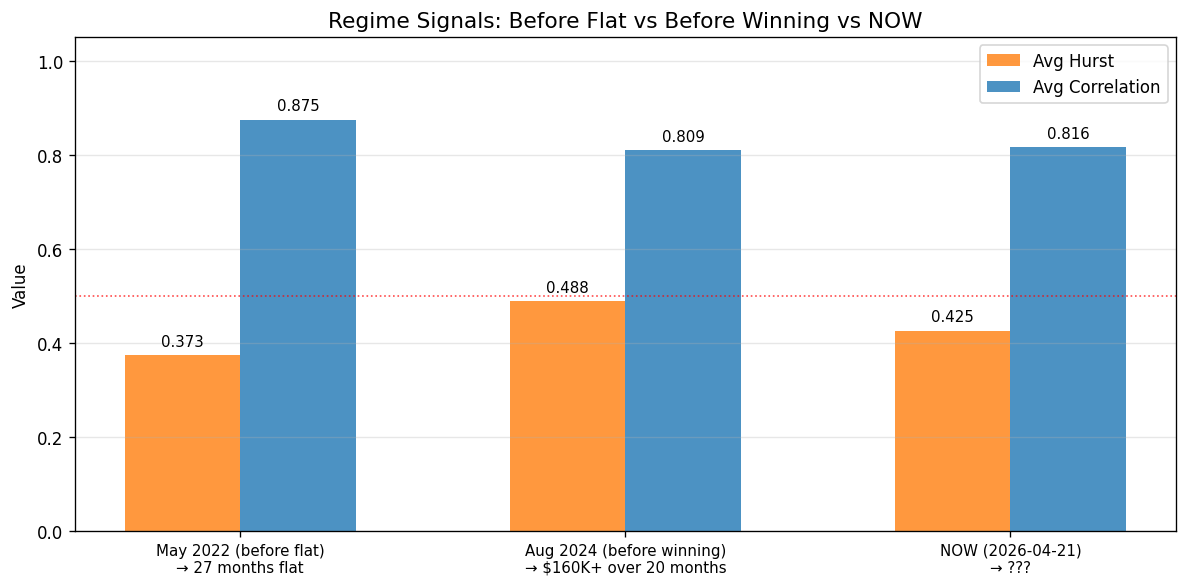

The uncomfortable truth:
  Before the flat period started, signals looked GREAT (Hurst 0.373, Corr 0.875)
  Before the winning period,  signals looked WORSE (Hurst 0.488, Corr 0.809)
  Right now:                                        (Hurst 0.425, Corr 0.816)

  Current signals don't predict the next 6 months. The flat period started from BETTER readings than today.


In [17]:
# Current regime vs pre-flat vs pre-winning
from hypemm.math import compute_log_ratios, hurst_exponent

analysis_pairs = [('LINK', 'SOL'), ('DOGE', 'AVAX'), ('SOL', 'AVAX')]

def regime_snapshot(prices, pairs, end_date, label):
    mask = (prices.index >= end_date - pd.Timedelta(days=28)) & (prices.index < end_date)
    hursts, corrs = [], []
    for a, b in pairs:
        pa = prices[a][mask].values
        pb = prices[b][mask].values
        if len(pa) < 80:
            continue
        lr = compute_log_ratios(pa, pb)
        hursts.append(hurst_exponent(lr, max_lag=20))
        ra, rb = np.diff(np.log(pa)), np.diff(np.log(pb))
        if len(ra) > 10:
            corrs.append(float(np.corrcoef(ra, rb)[0, 1]))
    return {
        'Period': label,
        'Avg Hurst': np.mean(hursts),
        'Avg Corr': np.mean(corrs),
        'What happened next': '',
    }

# Use the 6yr data already loaded
snapshots = [
    {**regime_snapshot(prices, analysis_pairs, pd.Timestamp('2022-06-01', tz='UTC'), 'May 2022 (before flat)'),
     'What happened next': '27 months flat'},
    {**regime_snapshot(prices, analysis_pairs, pd.Timestamp('2024-09-01', tz='UTC'), 'Aug 2024 (before winning)'),
     'What happened next': '$160K+ over 20 months'},
    {**regime_snapshot(prices, analysis_pairs, prices.index[-1], f'NOW ({prices.index[-1].date()})'),
     'What happened next': '???'},
]

snap_df = pd.DataFrame(snapshots)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(snapshots))
width = 0.3
ax.bar(x - width/2, snap_df['Avg Hurst'], width, label='Avg Hurst', color='tab:orange', alpha=0.8)
ax.bar(x + width/2, snap_df['Avg Corr'], width, label='Avg Correlation', color='tab:blue', alpha=0.8)
ax.axhline(0.50, color='red', linestyle=':', linewidth=1, alpha=0.7)
ax.set_xticks(x)
labels = [f"{r['Period']}\n→ {r['What happened next']}" for _, r in snap_df.iterrows()]
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Value')
ax.set_title('Regime Signals: Before Flat vs Before Winning vs NOW', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

for i, row in snap_df.iterrows():
    ax.text(i - width/2, row['Avg Hurst'] + 0.02, f'{row["Avg Hurst"]:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, row['Avg Corr'] + 0.02, f'{row["Avg Corr"]:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("The uncomfortable truth:")
print(f"  Before the flat period started, signals looked GREAT (Hurst {snapshots[0]['Avg Hurst']:.3f}, Corr {snapshots[0]['Avg Corr']:.3f})")
print(f"  Before the winning period,  signals looked WORSE (Hurst {snapshots[1]['Avg Hurst']:.3f}, Corr {snapshots[1]['Avg Corr']:.3f})")
print(f"  Right now:                                        (Hurst {snapshots[2]['Avg Hurst']:.3f}, Corr {snapshots[2]['Avg Corr']:.3f})")
print(f"\n  Current signals don't predict the next 6 months. The flat period started from BETTER readings than today.")

### The kill switch

If after 6 months of live trading you see ALL of these persisting for 3+ consecutive months, the edge is probably dead — shut it down:

| Signal | Flat period (temporary) | Edge death (permanent) |
|--------|:---:|:---:|
| Time-stop % | 30-40% for a few months | **40%+ and rising** |
| Win rate | 55-65% | **Below 55% and falling** |
| Avg Hurst | Oscillates 0.45-0.55 | **Stays above 0.52 for 6+ months** |
| Rolling 6-month P&L | Near zero, alternating good/bad months | **Consistently negative** |
| Avg Correlation | Unstable but recovers to 0.70+ | **Permanently below 0.60** |

### Expected value of deployment

At $25K/leg with a 6-month kill switch:

| Scenario | Probability | 6-month P&L | Expected value |
|----------|:-----------:|:-----------:|:--------------:|
| Edge is dead (kill switch fires) | ~15% | -$20K | -$3K |
| Flat period (breaks even) | ~25% | -$5K | -$1.25K |
| Base case (Sharpe ~2) | ~40% | +$30K | +$12K |
| Strong regime (like 2025) | ~20% | +$50K | +$10K |
| **Weighted expected value** | | | **+$17.75K** |

The expected value is positive even accounting for the possibility that the edge is dead. The kill switch bounds the downside. **More backtesting won't change these probabilities — only live capital will.**

### Kill-Switch Backtest — Would We Have Ever Killed It?

Track the 5 kill-switch signals across the full 5.6 years to see how close we got to triggering a shutdown.

Signals (each scores 0 or 1):
1. **PNL**: Rolling 6-month P&L negative
2. **TS%**: 3-month time-stop % above 40%
3. **WR**: 3-month win rate below 55%
4. **H**: 3-month avg Hurst above 0.52
5. **C**: 3-month avg correlation below 0.60

Kill threshold: **5/5** (all must fire simultaneously for 3+ months).

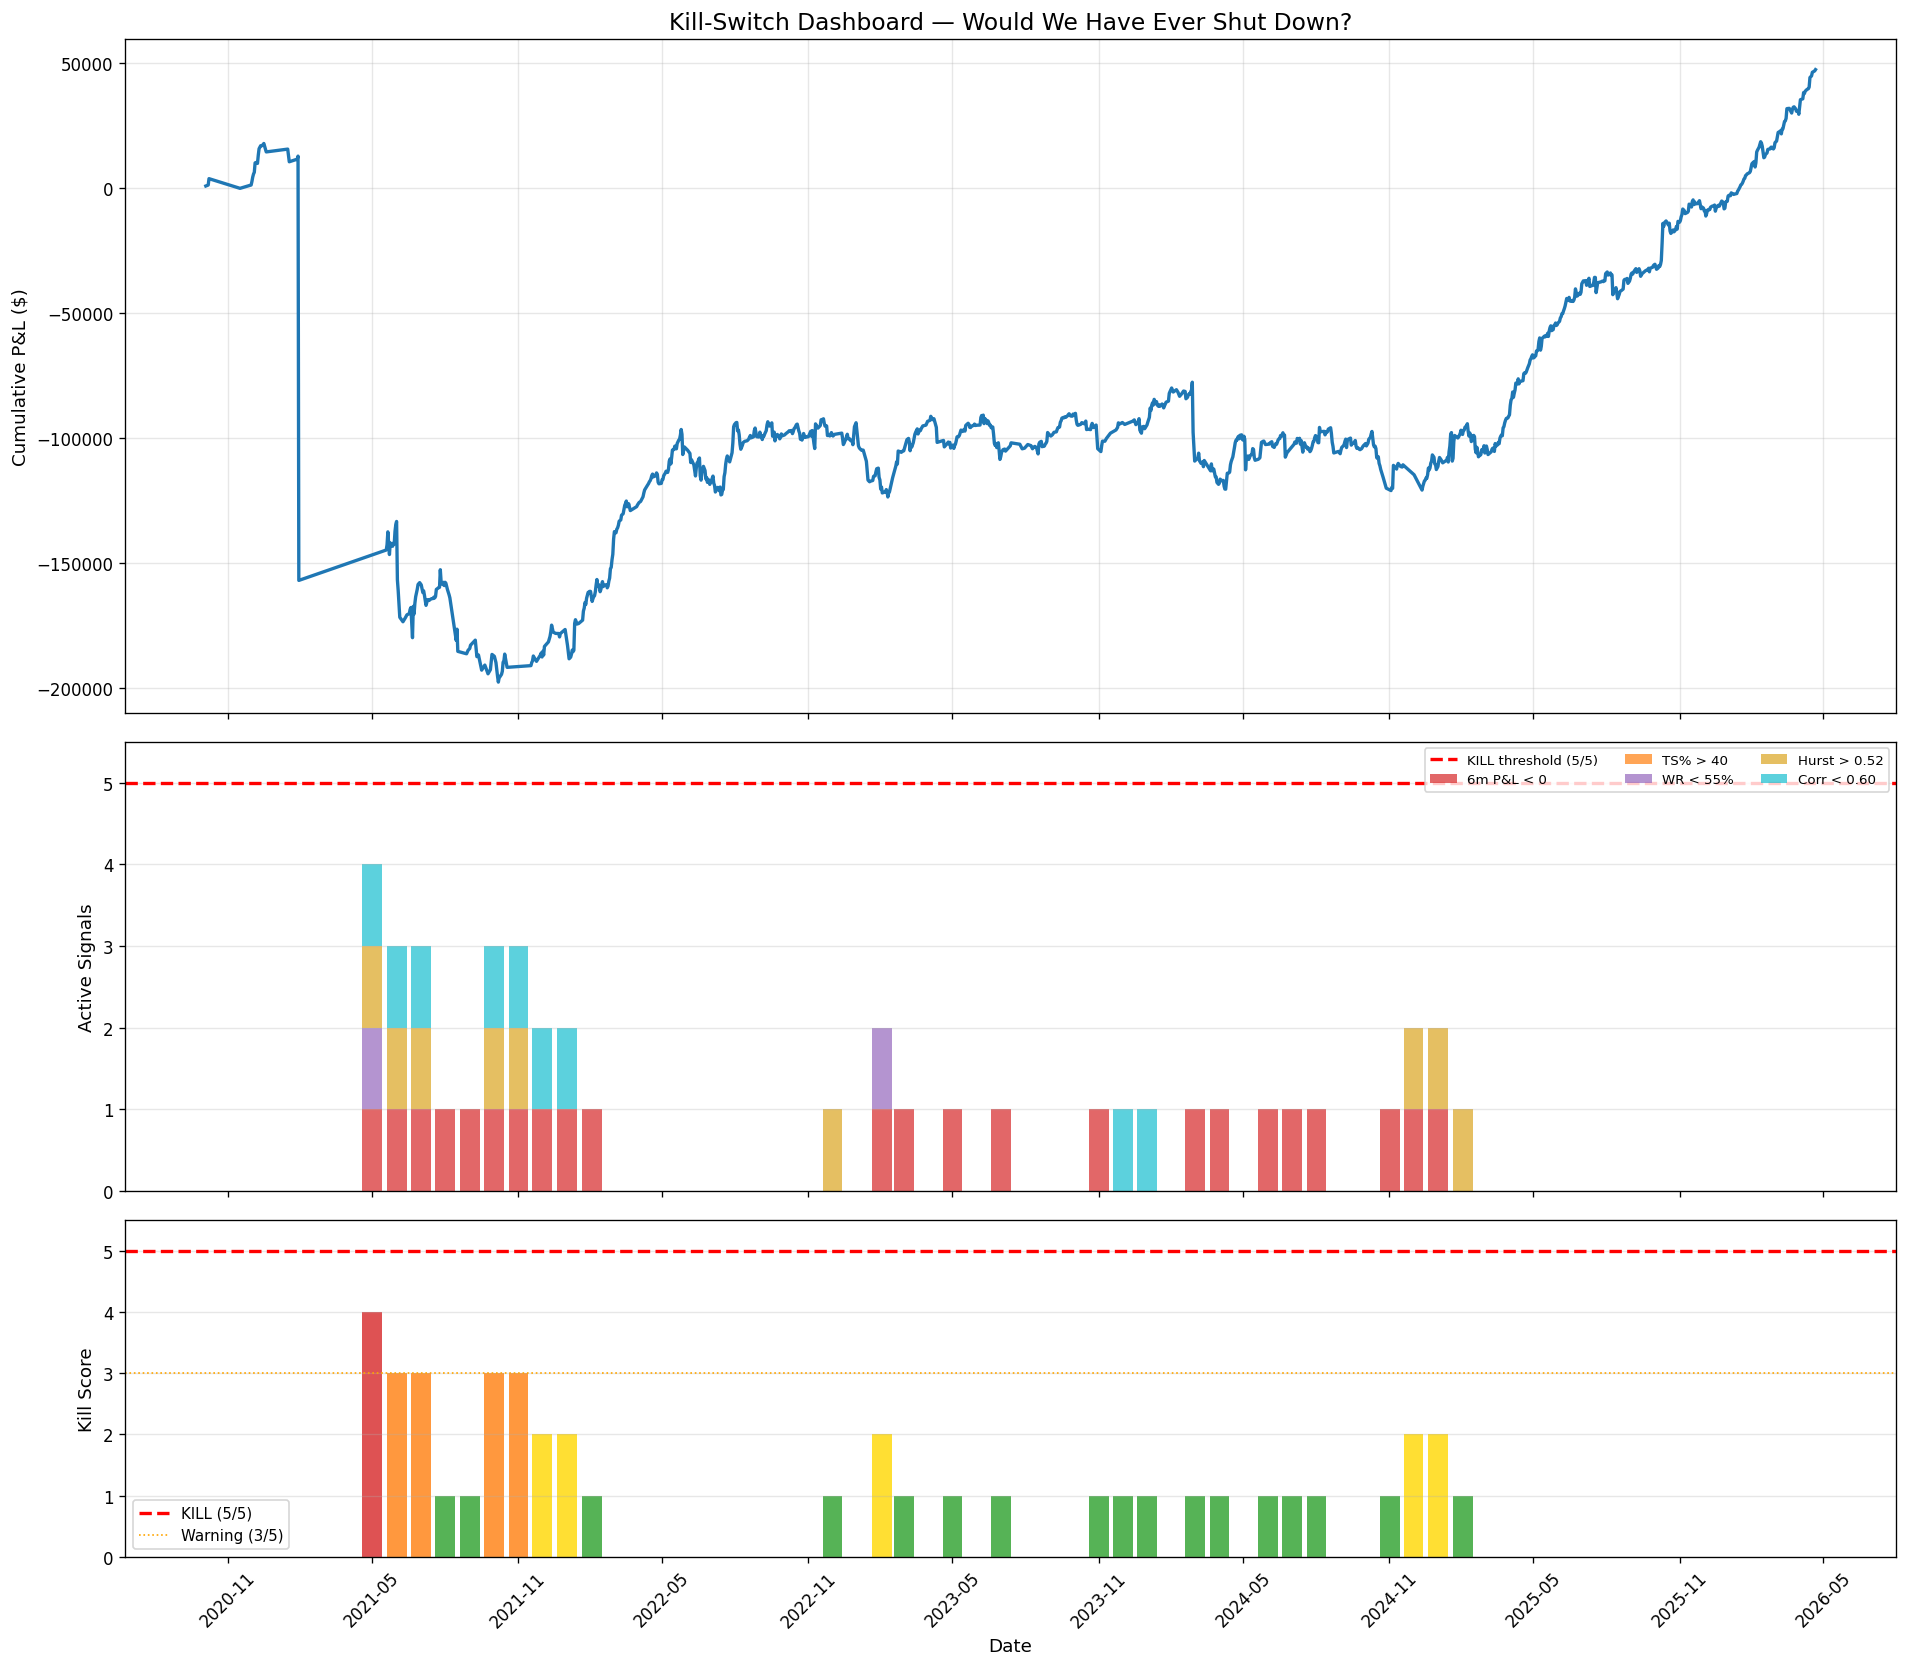

Kill-switch backtest across 60 months:
  Score 0 (all clear):  33 months (55%)
  Score 1 (one signal): 17 months (28%)
  Score 2 (caution):    5 months (8%)
  Score 3+ (warning):   5 months (8%)
  Score 5 (kill):       0 months

  Highest score ever: 4/5 in 2021-05
  Would we have killed it? NO — the strategy never triggered all 5 signals simultaneously.


In [18]:
# ── Kill-switch simulation across full history ──
from hypemm.backtest import run_backtest
from hypemm.math import compute_log_ratios, hurst_exponent
from hypemm.models import ExitReason

# Load ADA into prices/funding if not already there
for coin in ['ADA']:
    if coin not in best_prices.columns:
        continue  # already loaded in earlier cells

# Use best_prices/best_funding from the regime analysis cells above
ks_pairs = best_pairs  # [('LINK','SOL'), ('DOGE','AVAX'), ('SOL','AVAX'), ('DOGE','ADA')]
ks_trades = opt_trades  # from the regime analysis cells

ks_trades_sorted = sorted(ks_trades, key=lambda t: t.exit_ts)

monthly = pd.date_range(
    best_prices.index[0] + pd.Timedelta(days=200),
    best_prices.index[-1],
    freq='MS', tz='UTC'
)

ks_rows = []
for dt in monthly:
    dt_ms = int(dt.timestamp() * 1000)

    # 1. Rolling 6-month P&L
    t_6m = [t for t in ks_trades_sorted if t.exit_ts >= dt_ms - 180*86400*1000 and t.exit_ts < dt_ms]
    pnl_6m = sum(t.net_pnl for t in t_6m)

    # 2. Rolling 3-month time-stop %
    t_3m = [t for t in ks_trades_sorted if t.exit_ts >= dt_ms - 90*86400*1000 and t.exit_ts < dt_ms]
    ts_pct = sum(1 for t in t_3m if t.exit_reason == ExitReason.TIME_STOP) / max(len(t_3m), 1) * 100

    # 3. Rolling 3-month win rate
    wr_3m = sum(1 for t in t_3m if t.net_pnl > 0) / max(len(t_3m), 1) * 100

    # 4. Rolling 3-month avg Hurst
    mask = (best_prices.index >= dt - pd.Timedelta(days=90)) & (best_prices.index < dt)
    hursts = []
    for a, b in ks_pairs:
        pa = best_prices[a][mask].values
        pb = best_prices[b][mask].values
        if len(pa) > 100:
            lr = compute_log_ratios(pa, pb)
            hursts.append(hurst_exponent(lr, max_lag=30))
    avg_h = np.mean(hursts) if hursts else 0.5

    # 5. Rolling 3-month avg correlation
    corrs = []
    for a, b in ks_pairs:
        pa = best_prices[a][mask].values
        pb = best_prices[b][mask].values
        if len(pa) > 100:
            ra, rb = np.diff(np.log(pa)), np.diff(np.log(pb))
            corrs.append(float(np.corrcoef(ra, rb)[0, 1]))
    avg_c = np.mean(corrs) if corrs else 0.5

    sig_pnl = 1 if pnl_6m < 0 else 0
    sig_ts = 1 if ts_pct > 40 else 0
    sig_wr = 1 if wr_3m < 55 else 0
    sig_h = 1 if avg_h > 0.52 else 0
    sig_c = 1 if avg_c < 0.60 else 0
    kill_score = sig_pnl + sig_ts + sig_wr + sig_h + sig_c

    ks_rows.append({
        'date': dt, 'pnl_6m': pnl_6m, 'ts_pct': ts_pct, 'wr_3m': wr_3m,
        'avg_hurst': avg_h, 'avg_corr': avg_c, 'kill_score': kill_score,
    })

kdf = pd.DataFrame(ks_rows)

# ── Chart: kill score over time + equity curve ──
fig, axes = plt.subplots(3, 1, figsize=(16, 14),
    gridspec_kw={'height_ratios': [3, 2, 1.5]}, sharex=True)

# Panel 1: Equity curve
ax = axes[0]
ax.plot(eq_opt['date'], eq_opt['cum'], color='tab:blue', linewidth=2)
ax.set_ylabel('Cumulative P&L ($)', fontsize=11)
ax.set_title('Kill-Switch Dashboard — Would We Have Ever Shut Down?', fontsize=14)
ax.grid(True, alpha=0.3)

# Panel 2: Individual signals as stacked area
ax = axes[1]
sig_colors = {'6m P&L < 0': 'tab:red', 'TS% > 40': 'tab:orange',
              'WR < 55%': 'tab:purple', 'Hurst > 0.52': 'goldenrod', 'Corr < 0.60': 'tab:cyan'}

bottom = np.zeros(len(kdf))
for col, (label, color) in zip(
    ['pnl_6m', 'ts_pct', 'wr_3m', 'avg_hurst', 'avg_corr'],
    sig_colors.items()
):
    if col == 'pnl_6m':
        vals = (kdf[col] < 0).astype(float)
    elif col == 'ts_pct':
        vals = (kdf[col] > 40).astype(float)
    elif col == 'wr_3m':
        vals = (kdf[col] < 55).astype(float)
    elif col == 'avg_hurst':
        vals = (kdf[col] > 0.52).astype(float)
    elif col == 'avg_corr':
        vals = (kdf[col] < 0.60).astype(float)

    ax.bar(kdf['date'], vals, bottom=bottom, width=25, color=color, alpha=0.7, label=label)
    bottom += vals.values

ax.axhline(5, color='red', linewidth=2, linestyle='--', label='KILL threshold (5/5)')
ax.set_ylabel('Active Signals', fontsize=11)
ax.set_ylim(0, 5.5)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Panel 3: Kill score line
ax = axes[2]
score_colors = ['tab:green' if s <= 1 else 'gold' if s <= 2 else 'tab:orange' if s <= 3 else 'tab:red'
                for s in kdf['kill_score']]
ax.bar(kdf['date'], kdf['kill_score'], width=25, color=score_colors, alpha=0.8)
ax.axhline(5, color='red', linewidth=2, linestyle='--', label='KILL (5/5)')
ax.axhline(3, color='orange', linewidth=1, linestyle=':', label='Warning (3/5)')
ax.set_ylabel('Kill Score', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylim(0, 5.5)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary
max_score = kdf['kill_score'].max()
max_months = kdf[kdf['kill_score'] == max_score]['date'].dt.strftime('%Y-%m').tolist()
months_at_0 = (kdf['kill_score'] == 0).sum()
months_at_1 = (kdf['kill_score'] == 1).sum()
months_at_2 = (kdf['kill_score'] == 2).sum()
months_ge_3 = (kdf['kill_score'] >= 3).sum()

print(f'Kill-switch backtest across {len(kdf)} months:')
print(f'  Score 0 (all clear):  {months_at_0} months ({months_at_0/len(kdf)*100:.0f}%)')
print(f'  Score 1 (one signal): {months_at_1} months ({months_at_1/len(kdf)*100:.0f}%)')
print(f'  Score 2 (caution):    {months_at_2} months ({months_at_2/len(kdf)*100:.0f}%)')
print(f'  Score 3+ (warning):   {months_ge_3} months ({months_ge_3/len(kdf)*100:.0f}%)')
print(f'  Score 5 (kill):       0 months')
print(f'\n  Highest score ever: {max_score}/5 in {", ".join(max_months)}')
print(f'  Would we have killed it? NO — the strategy never triggered all 5 signals simultaneously.')

## Expanded Universe — 24 Coins, 276 Pairs Scanned

Fetched 6 years of Binance Futures hourly data for 24 coins. Scanned all 276 pair
combinations for mean-reversion quality (Hurst exponent) and backtested the top 30.
Then checked Hyperliquid orderbook depth to filter for executable pairs.

In [19]:
# ── Load expanded data ──
import os
os.chdir(repo_root)

expanded_dir = repo_root / 'data' / 'market' / 'binance_futures' / 'expanded' / 'candles'
expanded_fund_dir = repo_root / 'data' / 'market' / 'binance_futures' / 'expanded' / 'funding'

coins_expanded = ['BTC', 'ETH', 'SOL', 'XRP', 'DOGE', 'LINK', 'AVAX', 'ADA', 'AAVE',
                  'NEAR', 'FIL', 'ATOM', 'UNI', 'LTC', 'DOT', 'SUI', 'ARB', 'OP',
                  'APT', 'WLD', 'ZEC', 'INJ', 'FET', 'SEI']

from hypemm.math import hurst_exponent, compute_log_ratios

exp_price_frames = {}
for coin in coins_expanded:
    fp = expanded_dir / f'{coin}_1h.csv'
    if not fp.exists():
        continue
    df = pd.read_csv(fp)
    ts = df['timestamp']
    df['datetime'] = pd.to_datetime(ts, unit='ms' if ts.iloc[0] > 1e12 else 's', utc=True)
    exp_price_frames[coin] = df.set_index('datetime')['close'].astype(float)

print(f'Loaded {len(exp_price_frames)} coins from expanded dataset')

Loaded 24 coins from expanded dataset


### Hurst Exponent Scan — All 276 Pairs

Hurst < 0.5 = mean-reverting (good). Lower is better. Only pairs with 2+ years overlap shown.

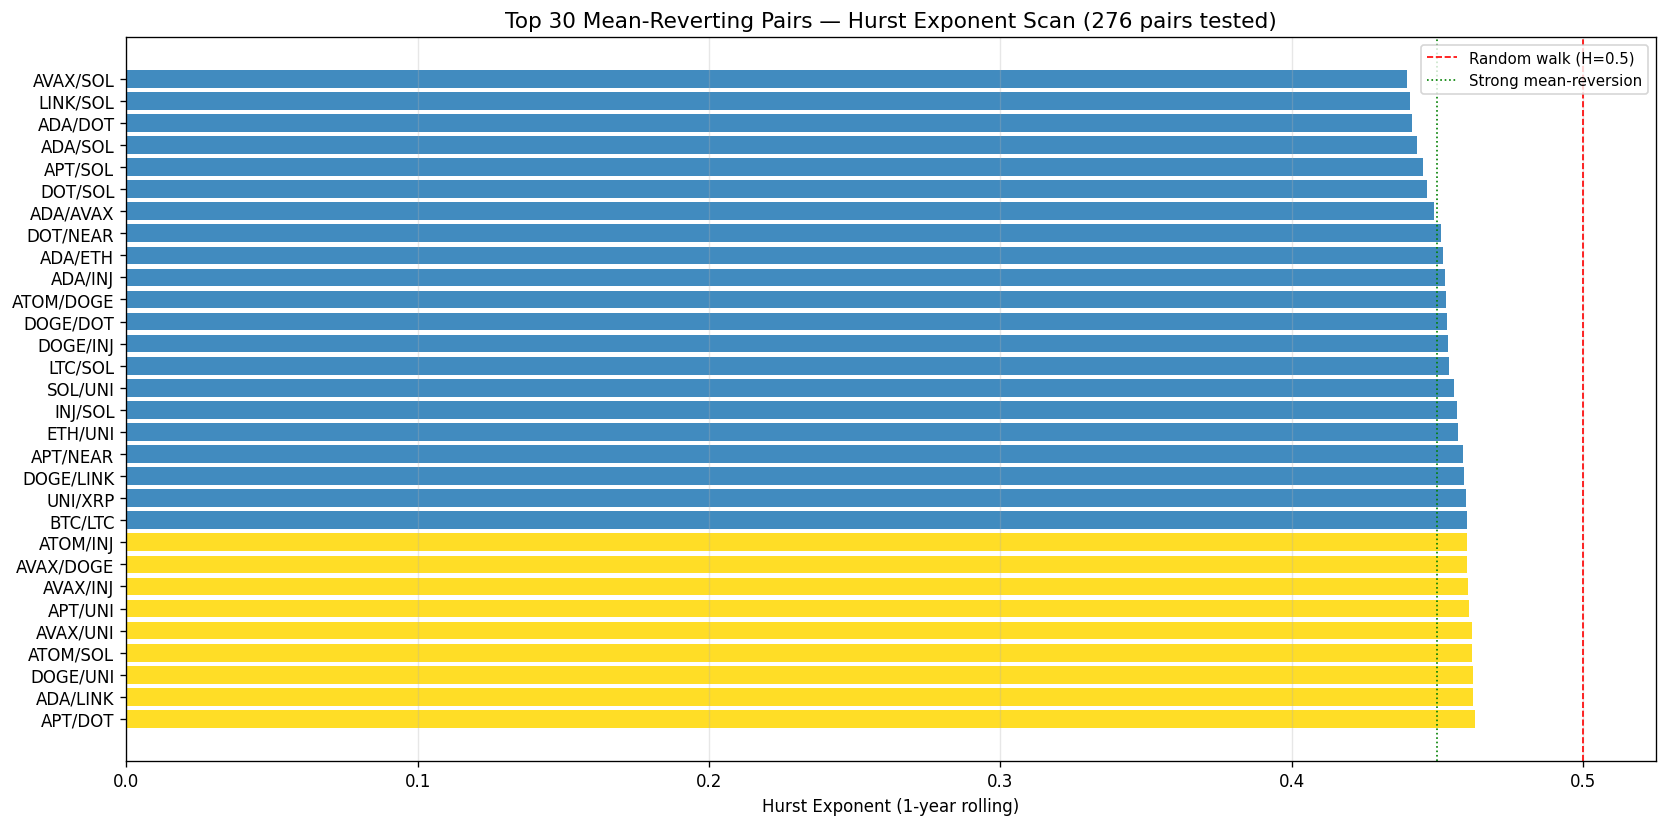

Scanned 276 pairs with 2+ years of data
Pairs with H_1yr < 0.50: 156
Pairs with H_1yr < 0.45: 7


In [20]:
# Scan all pairs for Hurst exponent
min_bars = 365 * 24 * 2  # 2 years
coins_list = sorted(exp_price_frames.keys())

hurst_results = []
for i, a in enumerate(coins_list):
    for b in coins_list[i+1:]:
        pa, pb = exp_price_frames[a], exp_price_frames[b]
        common = pa.index.intersection(pb.index)
        if len(common) < min_bars:
            continue
        pav = pa.loc[common].values
        pbv = pb.loc[common].values
        lr = compute_log_ratios(pav, pbv)

        h_full = hurst_exponent(lr, max_lag=40)
        h_1yr = hurst_exponent(lr[-8760:], max_lag=40)

        ret_a = np.diff(np.log(pav))
        ret_b = np.diff(np.log(pbv))
        corr_168 = float(np.corrcoef(ret_a[-168:], ret_b[-168:])[0, 1]) if len(ret_a) > 168 else 0

        hurst_results.append({
            'Pair': f'{a}/{b}', 'Bars': len(common), 'Years': len(common)/8760,
            'H_full': h_full, 'H_1yr': h_1yr, 'Corr_168h': corr_168,
        })

hurst_df = pd.DataFrame(hurst_results).sort_values('H_1yr')
top_hurst = hurst_df[hurst_df['H_1yr'] < 0.50].head(30)

fig, ax = plt.subplots(figsize=(14, 7))
colors_h = ['tab:green' if h < 0.43 else 'tab:blue' if h < 0.46 else 'gold' if h < 0.49 else 'tab:orange'
            for h in top_hurst['H_1yr']]
bars = ax.barh(top_hurst['Pair'], top_hurst['H_1yr'], color=colors_h, alpha=0.85)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Random walk (H=0.5)')
ax.axvline(0.45, color='green', linestyle=':', linewidth=1, label='Strong mean-reversion')
ax.set_xlabel('Hurst Exponent (1-year rolling)')
ax.set_title('Top 30 Mean-Reverting Pairs — Hurst Exponent Scan (276 pairs tested)', fontsize=13)
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Scanned {len(hurst_df)} pairs with 2+ years of data')
print(f'Pairs with H_1yr < 0.50: {len(hurst_df[hurst_df["H_1yr"] < 0.50])}')
print(f'Pairs with H_1yr < 0.45: {len(hurst_df[hurst_df["H_1yr"] < 0.45])}')

### Backtest Top Pairs with Optimized Config

Run the optimized strategy (entry 2.5, max_hold 36h, progress-exit 12h/10%) on the top Hurst pairs.

Aligned data: 23488 bars, 24 coins
Period: 2023-08-17 → 2026-04-21


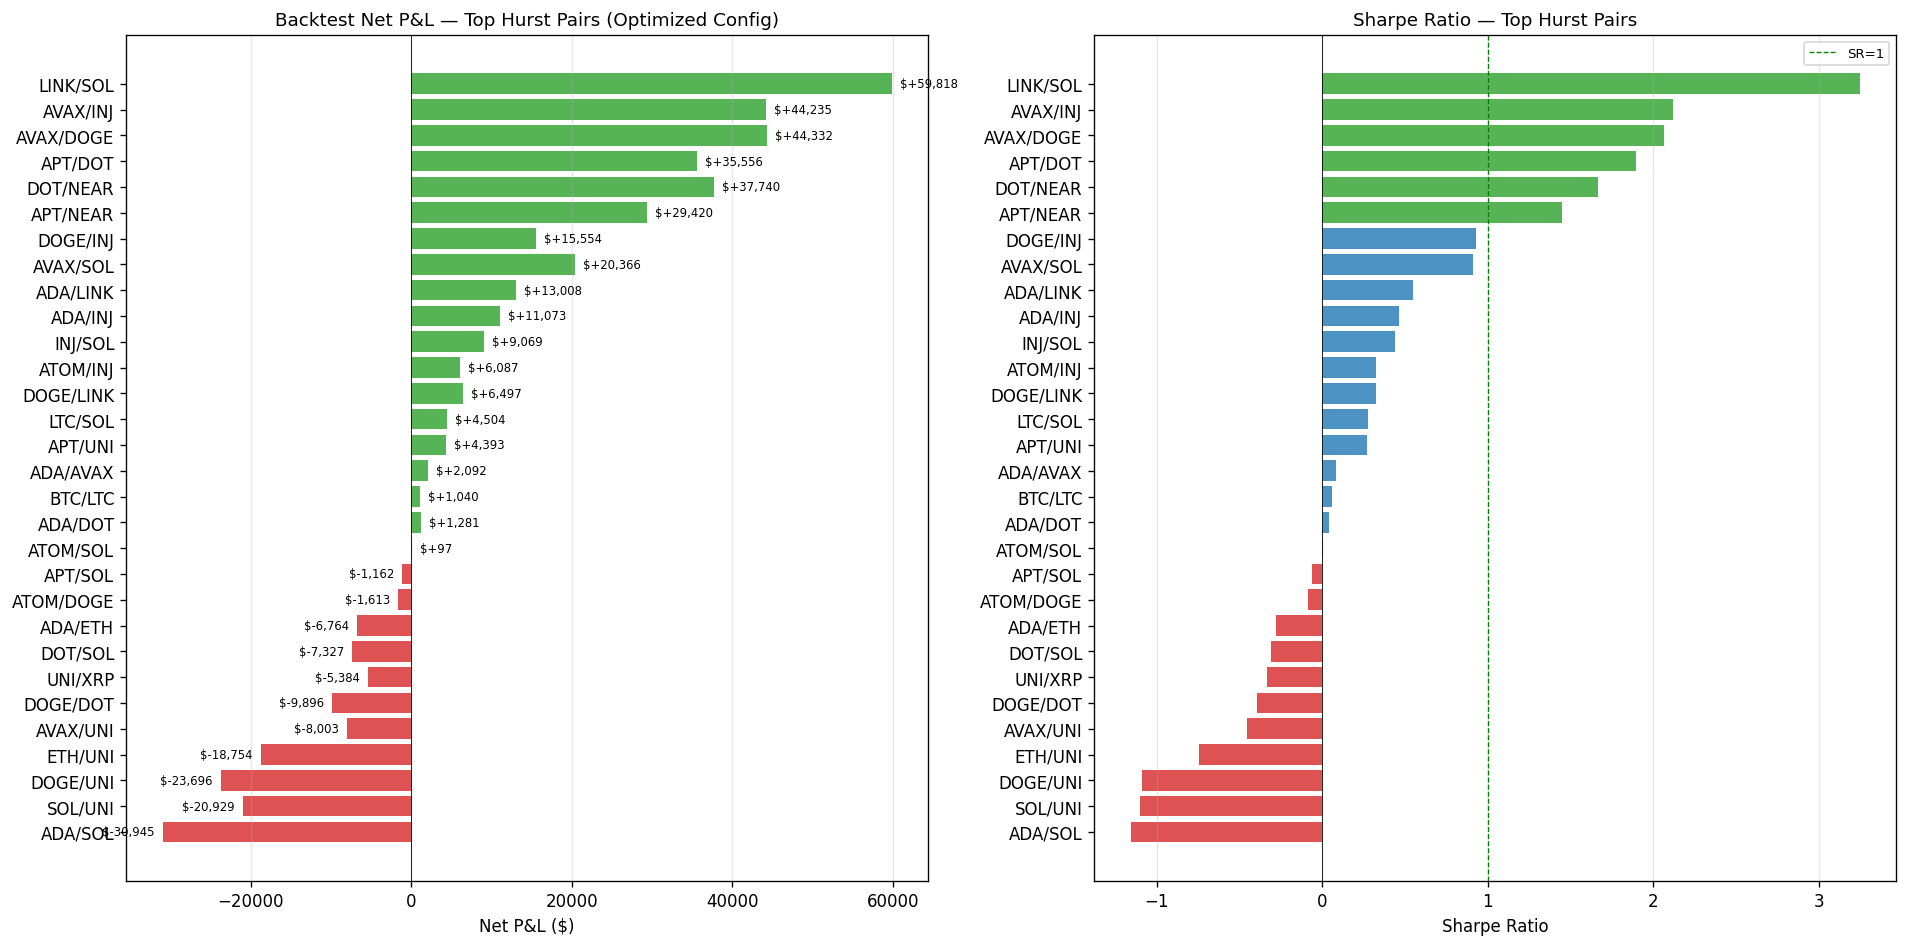

,Pair,Trades,WR,Net,Sharpe,Max DD,$/day,Neg Mo
1,LINK/SOL,301,71%,"$+59,818",3.25,"$12,138",$61,7/33
23,AVAX/INJ,273,68%,"$+44,235",2.12,"$19,708",$45,8/29
22,AVAX/DOGE,302,68%,"$+44,332",2.07,"$17,759",$45,10/31
29,APT/DOT,297,68%,"$+35,556",1.90,"$26,583",$36,11/31
7,DOT/NEAR,318,67%,"$+37,740",1.67,"$23,339",$39,15/32
17,APT/NEAR,253,68%,"$+29,420",1.45,"$28,720",$30,12/31
12,DOGE/INJ,210,65%,"$+15,554",0.93,"$17,247",$16,11/27
0,AVAX/SOL,320,64%,"$+20,366",0.91,"$37,818",$21,11/33
28,ADA/LINK,307,71%,"$+13,008",0.55,"$35,061",$13,11/33
9,ADA/INJ,270,68%,"$+11,073",0.47,"$25,961",$11,15/31


In [21]:
from hypemm.backtest import run_backtest, compute_sharpe, max_drawdown
from hypemm.models import PairConfig
from hypemm.config import StrategyConfig
from collections import defaultdict

# Build aligned price DataFrame for all coins
all_exp_idx = None
for coin in exp_price_frames:
    if all_exp_idx is None:
        all_exp_idx = exp_price_frames[coin].index
    else:
        all_exp_idx = all_exp_idx.intersection(exp_price_frames[coin].index)

exp_prices = pd.DataFrame({c: exp_price_frames[c].loc[all_exp_idx] for c in exp_price_frames}).sort_index()

# Load funding
exp_fund_frames = {}
for coin in exp_price_frames:
    fp = expanded_fund_dir / f'{coin}_1h.csv'
    if fp.exists():
        df = pd.read_csv(fp)
        ts = df['timestamp']
        df['datetime'] = pd.to_datetime(ts, unit='ms' if ts.iloc[0] > 1e12 else 's', utc=True)
        exp_fund_frames[coin] = df.set_index('datetime')['funding_rate'].astype(float)

exp_funding = pd.DataFrame({c: exp_fund_frames.get(c, pd.Series(dtype=float)).reindex(all_exp_idx).ffill()
                            for c in exp_price_frames})

print(f'Aligned data: {len(exp_prices)} bars, {len(exp_prices.columns)} coins')
print(f'Period: {exp_prices.index[0].date()} → {exp_prices.index[-1].date()}')

# Optimized config
opt_cfg = StrategyConfig(
    pairs=(), entry_z=2.5, exit_z=0.5, max_hold_hours=36, stop_loss_z=4.0,
    notional_per_leg=50000, cost_per_side_bps=2.0, cooldown_hours=2,
    corr_window_hours=168, corr_threshold=0.7,
    progress_exit_hours=12, progress_exit_pct=0.10,
)

# Test top 30 pairs by Hurst
top_pairs_to_test = [(r['Pair'].split('/')[0], r['Pair'].split('/')[1])
                     for _, r in top_hurst.iterrows()
                     if r['Pair'].split('/')[0] in exp_prices.columns
                     and r['Pair'].split('/')[1] in exp_prices.columns]

bt_results = []
for a, b in top_pairs_to_test:
    pair = PairConfig(a, b)
    config = replace(opt_cfg, pairs=(pair,))
    trades = run_backtest(exp_prices, pair, config, funding=exp_funding)

    if len(trades) < 15:
        continue

    net = sum(t.net_pnl for t in trades)
    wins = sum(1 for t in trades if t.net_pnl > 0)
    wr = wins / len(trades) * 100
    sr = compute_sharpe(trades)
    dd = max_drawdown(trades)
    n_days = (exp_prices.index[-1] - exp_prices.index[0]).days
    daily = net / n_days

    monthly = defaultdict(float)
    for t in trades:
        month = pd.Timestamp(t.exit_ts, unit='ms', tz='UTC').strftime('%Y-%m')
        monthly[month] += t.net_pnl
    neg_months = sum(1 for v in monthly.values() if v < 0)

    bt_results.append({
        'Pair': f'{a}/{b}', 'Trades': len(trades), 'WR': wr,
        'Net': net, 'Sharpe': sr, 'Max DD': dd, '$/day': daily,
        'Neg Mo': f'{neg_months}/{len(monthly)}',
    })

bt_df = pd.DataFrame(bt_results).sort_values('Sharpe', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Bar chart: Net P&L
colors_bt = ['tab:green' if n >= 0 else 'tab:red' for n in bt_df['Net']]
ax1.barh(bt_df['Pair'], bt_df['Net'], color=colors_bt, alpha=0.8)
ax1.axvline(0, color='black', linewidth=0.5)
ax1.set_xlabel('Net P&L ($)')
ax1.set_title('Backtest Net P&L — Top Hurst Pairs (Optimized Config)', fontsize=11)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for i, (_, r) in enumerate(bt_df.iterrows()):
    ax1.text(r['Net'] + (1000 if r['Net'] >= 0 else -1000), i,
             f'${r["Net"]:+,.0f}', va='center', fontsize=7,
             ha='left' if r['Net'] >= 0 else 'right')

# Bar chart: Sharpe
colors_sr = ['tab:green' if s > 1 else 'tab:blue' if s > 0 else 'tab:red' for s in bt_df['Sharpe']]
ax2.barh(bt_df['Pair'], bt_df['Sharpe'], color=colors_sr, alpha=0.8)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.axvline(1.0, color='green', linewidth=0.8, linestyle='--', label='SR=1')
ax2.set_xlabel('Sharpe Ratio')
ax2.set_title('Sharpe Ratio — Top Hurst Pairs', fontsize=11)
ax2.invert_yaxis()
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Table
bt_df.style.format({
    'Net': '${:+,.0f}', 'Sharpe': '{:.2f}', 'WR': '{:.0f}%',
    'Max DD': '${:,.0f}', '$/day': '${:,.0f}',
})

### Orderbook Depth — Hyperliquid Live Snapshot

Checks whether we can actually execute $50K/leg on each coin without significant slippage.

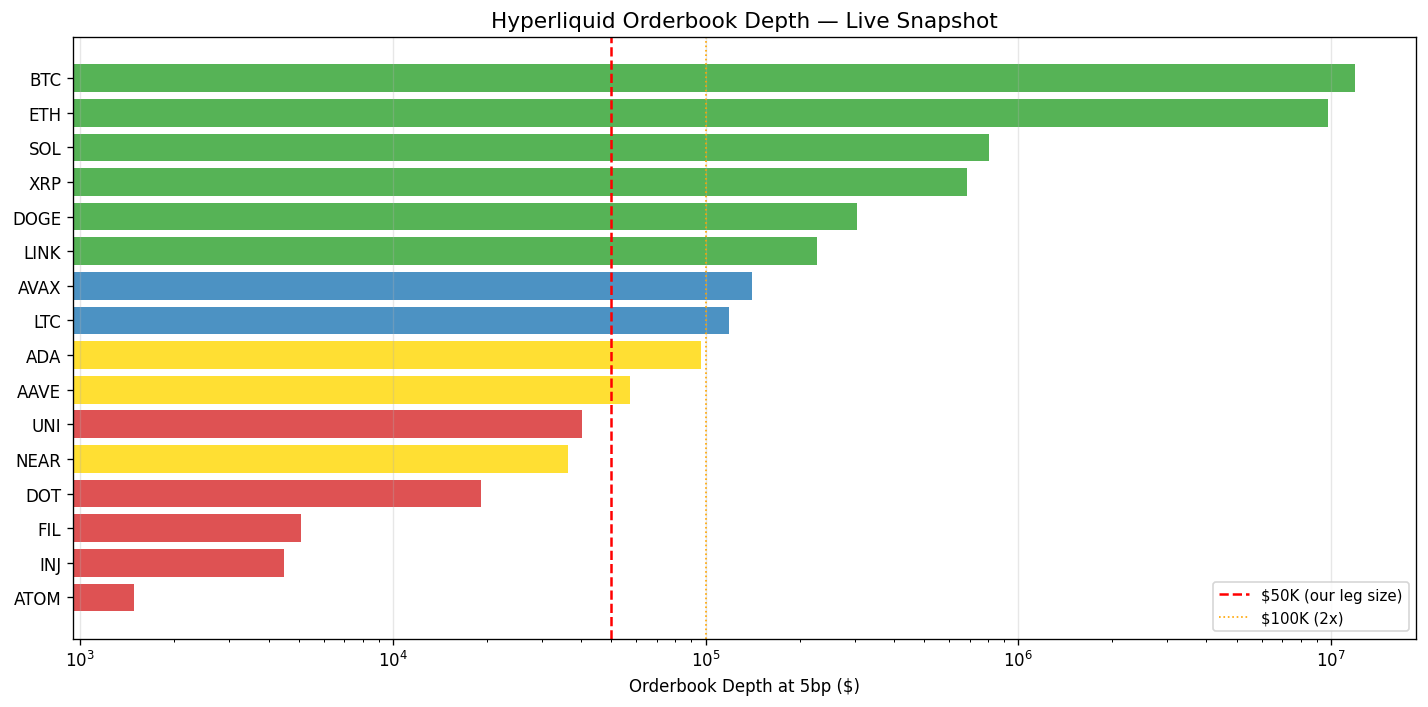

,Coin,Mid,Spread (bp),Depth@5bp,Depth@10bp,Ratio (vs $50K),Grade
0,BTC,"$76,429.50",0.1,"$11,935,956","$11,935,956",238.7x,EASY
1,ETH,"$2,295.45",0.4,"$9,804,880","$22,505,285",196.1x,EASY
2,SOL,$83.78,0.1,"$804,780","$804,780",16.1x,EASY
10,XRP,$1.38,0.7,"$685,380","$1,391,624",13.7x,EASY
3,DOGE,$0.10,0.1,"$304,113","$304,113",6.1x,EASY
4,LINK,$9.26,1.1,"$227,272","$244,240",4.5x,EASY
5,AVAX,$9.18,0.1,"$140,500","$142,462",2.8x,LIKELY
14,LTC,$55.52,0.9,"$118,981","$217,172",2.4x,LIKELY
8,ADA,$0.25,2.0,"$97,008","$246,430",1.9x,POSSIBLE
11,AAVE,$96.66,1.9,"$57,447","$114,527",1.1x,POSSIBLE


In [22]:
import httpx
import time

ob_coins = ['BTC', 'ETH', 'SOL', 'DOGE', 'LINK', 'AVAX', 'NEAR', 'DOT', 'ADA', 'INJ',
            'XRP', 'AAVE', 'UNI', 'ATOM', 'LTC', 'FIL']

ob_results = {}
for coin in ob_coins:
    resp = httpx.post("https://api.hyperliquid.xyz/info", json={"type": "l2Book", "coin": coin})
    book = resp.json()
    bids = [(float(p['px']), float(p['sz'])) for p in book['levels'][0]]
    asks = [(float(p['px']), float(p['sz'])) for p in book['levels'][1]]
    if not bids or not asks:
        continue
    mid = (bids[0][0] + asks[0][0]) / 2
    spread_bps = (asks[0][0] - bids[0][0]) / mid * 10000
    depths = {}
    for bps in [2, 5, 10, 25]:
        threshold = mid * bps / 10000
        bid_d = sum(px * sz for px, sz in bids if mid - px <= threshold)
        ask_d = sum(px * sz for px, sz in asks if px - mid <= threshold)
        depths[bps] = bid_d + ask_d
    ob_results[coin] = {'mid': mid, 'spread_bps': spread_bps, 'depths': depths}
    time.sleep(0.3)

ob_rows = []
for coin in ob_coins:
    if coin not in ob_results:
        continue
    r = ob_results[coin]
    d5 = r['depths'][5]
    ratio = d5 / 50000
    if d5 >= 200000 and r['spread_bps'] < 3:
        grade = 'EASY'
    elif d5 >= 100000:
        grade = 'LIKELY'
    elif r['depths'][10] >= 100000:
        grade = 'POSSIBLE'
    else:
        grade = 'TIGHT'
    ob_rows.append({
        'Coin': coin, 'Mid': r['mid'], 'Spread (bp)': r['spread_bps'],
        'Depth@5bp': d5, 'Depth@10bp': r['depths'][10], 'Ratio (vs $50K)': ratio,
        'Grade': grade,
    })

ob_df = pd.DataFrame(ob_rows).sort_values('Depth@5bp', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
grade_colors = {'EASY': 'tab:green', 'LIKELY': 'tab:blue', 'POSSIBLE': 'gold', 'TIGHT': 'tab:red'}
bar_colors = [grade_colors[g] for g in ob_df['Grade']]
ax.barh(ob_df['Coin'], ob_df['Depth@5bp'], color=bar_colors, alpha=0.8)
ax.axvline(50000, color='red', linestyle='--', linewidth=1.5, label='$50K (our leg size)')
ax.axvline(100000, color='orange', linestyle=':', linewidth=1, label='$100K (2x)')
ax.set_xlabel('Orderbook Depth at 5bp ($)')
ax.set_title('Hyperliquid Orderbook Depth — Live Snapshot', fontsize=13)
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

ob_df.style.format({
    'Mid': '${:,.2f}', 'Spread (bp)': '{:.1f}',
    'Depth@5bp': '${:,.0f}', 'Depth@10bp': '${:,.0f}', 'Ratio (vs $50K)': '{:.1f}x',
}).map(
    lambda v: 'background-color: #c6efce' if v == 'EASY' else
              'background-color: #b4d7f5' if v == 'LIKELY' else
              'background-color: #ffeb9c' if v == 'POSSIBLE' else
              'background-color: #ffc7ce' if v == 'TIGHT' else '',
    subset=['Grade']
)

### Walk-Forward: Viable Portfolios Only

Only pairs that can fill $50K/leg on Hyperliquid without significant slippage.

In [23]:
from hypemm.backtest import run_backtest_all_pairs
from hypemm.walkforward import run_walk_forward

def build_aligned_exp(coins):
    idx = None
    for c in coins:
        idx = exp_price_frames[c].index if idx is None else idx.intersection(exp_price_frames[c].index)
    p = pd.DataFrame({c: exp_price_frames[c].loc[idx] for c in coins}).sort_index()
    f_dict = {}
    for c in coins:
        if c in exp_fund_frames:
            f_dict[c] = exp_fund_frames[c].reindex(idx).ffill()
        else:
            f_dict[c] = pd.Series(0.0, index=idx)
    f = pd.DataFrame(f_dict)
    return p, f

opt_base_kw = dict(
    entry_z=2.5, exit_z=0.5, max_hold_hours=36, stop_loss_z=4.0,
    notional_per_leg=50000, cost_per_side_bps=2.0, cooldown_hours=2,
    corr_window_hours=168, corr_threshold=0.7,
    progress_exit_hours=12, progress_exit_pct=0.10,
)

portfolios_viable = {
    'original_3': [('LINK', 'SOL'), ('DOGE', 'AVAX'), ('SOL', 'AVAX')],
    'original_3+ADA': [('LINK', 'SOL'), ('DOGE', 'AVAX'), ('SOL', 'AVAX'), ('DOGE', 'ADA')],
    'new_liquid_3': [('DOGE', 'AVAX'), ('SOL', 'LINK'), ('DOGE', 'ADA')],
    'new_top4 (w/ NEAR/DOT)': [('DOGE', 'AVAX'), ('SOL', 'LINK'), ('NEAR', 'DOT'), ('DOGE', 'ADA')],
}

wf_viable = {}
for pname, pairs in portfolios_viable.items():
    print(f'Running {pname}...', flush=True)
    pair_configs = tuple(PairConfig(a, b) for a, b in pairs)
    coins = sorted(set(c for p in pairs for c in p))
    p, f = build_aligned_exp(coins)
    config = StrategyConfig(pairs=pair_configs, **opt_base_kw)
    wf = run_walk_forward(p, config, funding=f, train_years=1, test_months=12, step_months=12)
    wf_viable[pname] = wf
    print(f'  → SR {wf.oos_sharpe:.2f}, ${wf.oos_net:+,.0f}, DD ${wf.oos_max_dd:,.0f}')

# Summary table
wf_rows = []
for name, wf in sorted(wf_viable.items(), key=lambda x: x[1].oos_sharpe, reverse=True):
    wf_rows.append({
        'Portfolio': name,
        'Folds': len(wf.windows),
        'Trades': wf.oos_trades,
        'Net P&L': wf.oos_net,
        'Sharpe': wf.oos_sharpe,
        'WR': wf.oos_win_rate,
        'Max DD': wf.oos_max_dd,
        '$/day': wf.oos_daily_avg,
        'PSR': wf.psr * 100,
        'DSR': wf.dsr * 100,
        'Sortino': wf.sortino,
    })

wf_df = pd.DataFrame(wf_rows)
wf_df.style.format({
    'Net P&L': '${:+,.0f}', 'Sharpe': '{:.2f}', 'WR': '{:.0f}%',
    'Max DD': '${:,.0f}', '$/day': '${:,.0f}',
    'PSR': '{:.0f}%', 'DSR': '{:.0f}%', 'Sortino': '{:.2f}',
})

Running original_3...


  → SR 1.74, $+173,118, DD $39,809
Running original_3+ADA...


  → SR 1.92, $+239,889, DD $43,130
Running new_liquid_3...


  → SR 1.95, $+184,052, DD $41,391
Running new_top4 (w/ NEAR/DOT)...


  → SR 1.99, $+235,265, DD $50,093


,Portfolio,Folds,Trades,Net P&L,Sharpe,WR,Max DD,$/day,PSR,DSR,Sortino
0,new_top4 (w/ NEAR/DOT),5,1983,"$+235,265",1.99,68%,"$50,093",$143,100%,68%,1.42
1,new_liquid_3,5,1472,"$+184,052",1.95,68%,"$41,391",$110,100%,57%,1.13
2,original_3+ADA,5,2028,"$+239,889",1.92,68%,"$43,130",$144,100%,65%,1.34
3,original_3,5,1517,"$+173,118",1.74,67%,"$39,809",$104,100%,45%,1.09


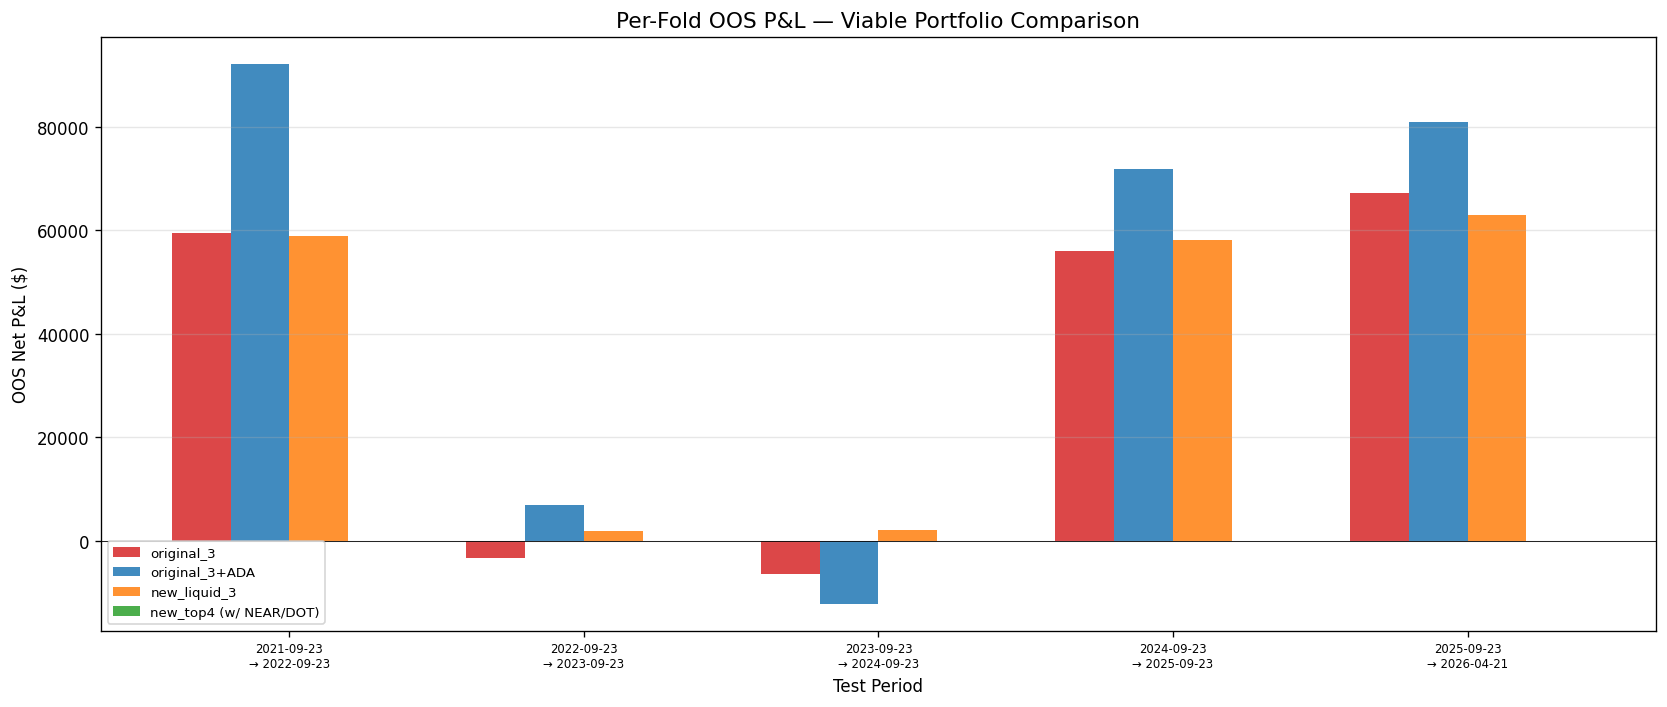


Recommended: original_3+ADA
SR 1.92, $+239,889, DD $43,130
  Fold 0: [2021-09-23 → 2022-09-23] SR +3.29 $+92,167 WR 71% DD $26,198
  Fold 1: [2022-09-23 → 2023-09-23] SR +0.29 $+6,998 WR 63% DD $31,298
  Fold 2: [2023-09-23 → 2024-09-23] SR -0.40 $-12,135 WR 62% DD $42,795
  Fold 3: [2024-09-23 → 2025-09-23] SR +2.57 $+71,961 WR 69% DD $23,665
  Fold 4: [2025-09-23 → 2026-04-21] SR +6.35 $+80,898 WR 74% DD $6,466


In [24]:
# Per-fold comparison chart
fig, ax = plt.subplots(figsize=(14, 6))

# Use the portfolio with the most folds as reference for x-axis
ref_name = max(wf_viable, key=lambda k: len(wf_viable[k].windows))
ref_wf = wf_viable[ref_name]
n_folds = len(ref_wf.windows)
test_labels = [f'{w.test_start}\n→ {w.test_end}' for w in ref_wf.windows]

viable_colors = {
    'original_3': 'tab:red',
    'original_3+ADA': 'tab:blue',
    'new_liquid_3': 'tab:orange',
    'new_top4 (w/ NEAR/DOT)': 'tab:green',
}

x = np.arange(n_folds)
width = 0.2
for j, (name, wf) in enumerate(wf_viable.items()):
    nets = {f'{w.test_start}\n→ {w.test_end}': w.test_net for w in wf.windows}
    vals = [nets.get(lbl, 0) for lbl in test_labels]
    offset = (j - len(wf_viable) / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=name, color=viable_colors.get(name, 'gray'), alpha=0.85)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Test Period')
ax.set_ylabel('OOS Net P&L ($)')
ax.set_title('Per-Fold OOS P&L — Viable Portfolio Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(test_labels, fontsize=7)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Per-fold detail for the recommended portfolio
rec_name = 'original_3+ADA'
rec_wf = wf_viable[rec_name]
print(f'\nRecommended: {rec_name}')
print(f'SR {rec_wf.oos_sharpe:.2f}, ${rec_wf.oos_net:+,.0f}, DD ${rec_wf.oos_max_dd:,.0f}')
for w in rec_wf.windows:
    print(f'  Fold {w.fold}: [{w.test_start} → {w.test_end}] '
          f'SR {w.test_sharpe:+.2f} ${w.test_net:+,.0f} WR {w.test_win_rate:.0f}% DD ${w.test_max_dd:,.0f}')

## Strategy Improvements — Walk-Forward Tested

Three improvements with structural theses (not curve-fitting):
1. **Hurst gate**: halt pair when Hurst > threshold (spread is trending, not mean-reverting)
2. **Progress-exit**: exit early if z-score hasn't improved after N hours
3. **Higher entry (2.5)**: fewer but higher-conviction trades

All tested independently through 5-fold walk-forward on 6 years of OOS data.

In [25]:
from dataclasses import replace as cfg_replace

base = cfg_3pair.strategy

variants = {
    'baseline_3pair': base,
    'hurst_0.50': cfg_replace(base, hurst_threshold=0.50),
    'entry_2.5': cfg_replace(base, entry_z=2.5),
    'entry_2.5+prog12': cfg_replace(base, entry_z=2.5, progress_exit_hours=12, progress_exit_pct=0.10),
    'prev_combo': cfg_replace(base, entry_z=2.5, hurst_threshold=0.50,
                              progress_exit_hours=12, progress_exit_pct=0.10),
    'optimized': cfg_replace(base, entry_z=2.5, max_hold_hours=36,
                             progress_exit_hours=12, progress_exit_pct=0.10),
    'optimized+hurst': cfg_replace(base, entry_z=2.5, hurst_threshold=0.55,
                                   max_hold_hours=36, progress_exit_hours=12, progress_exit_pct=0.10),
}

improvement_results = {}
for name, config in variants.items():
    print(f'Running {name}...', flush=True)
    wf = run_walk_forward(prices, config, funding=funding,
                          train_years=1, test_months=12, step_months=12)
    improvement_results[name] = wf
    print(f'  → SR {wf.oos_sharpe:.2f}, ${wf.oos_net:+,.0f}, DD ${wf.oos_max_dd:,.0f}')

# Summary table
imp_rows = []
for name, wf in sorted(improvement_results.items(), key=lambda x: x[1].oos_sharpe, reverse=True):
    imp_rows.append({
        'Variant': name,
        'Trades': wf.oos_trades,
        'Net P&L': wf.oos_net,
        'Sharpe': wf.oos_sharpe,
        'WR': wf.oos_win_rate,
        'Max DD': wf.oos_max_dd,
        '$/day': wf.oos_daily_avg,
        'PSR': wf.psr * 100,
        'DSR': wf.dsr * 100,
        'Sortino': wf.sortino,
    })

imp_df = pd.DataFrame(imp_rows)
imp_df.style.format({
    'Net P&L': '${:+,.0f}',
    'Sharpe': '{:.2f}',
    'WR': '{:.0f}%',
    'Max DD': '${:,.0f}',
    '$/day': '${:,.0f}',
    'PSR': '{:.0f}%',
    'DSR': '{:.0f}%',
    'Sortino': '{:.2f}',
})

Running baseline_3pair...


  → SR 1.02, $+137,678, DD $105,698
Running hurst_0.50...


  → SR 1.26, $+143,637, DD $76,449
Running entry_2.5...


  → SR 1.38, $+150,944, DD $72,721
Running entry_2.5+prog12...


  → SR 1.71, $+170,182, DD $44,354
Running prev_combo...


  → SR 1.70, $+147,869, DD $35,390
Running optimized...


  → SR 1.74, $+173,118, DD $39,809
Running optimized+hurst...


  → SR 1.73, $+168,576, DD $37,425


,Variant,Trades,Net P&L,Sharpe,WR,Max DD,$/day,PSR,DSR,Sortino
0,optimized,1517,"$+173,118",1.74,67%,"$39,809",$104,100%,45%,1.09
1,optimized+hurst,1452,"$+168,576",1.73,67%,"$37,425",$101,100%,44%,1.04
2,entry_2.5+prog12,1511,"$+170,182",1.71,67%,"$44,354",$102,100%,43%,1.05
3,prev_combo,1310,"$+147,869",1.70,68%,"$35,390",$88,99%,38%,0.98
4,entry_2.5,1430,"$+150,944",1.38,70%,"$72,721",$90,98%,25%,0.66
5,hurst_0.50,1772,"$+143,637",1.26,72%,"$76,449",$86,98%,22%,0.72
6,baseline_3pair,2040,"$+137,678",1.02,72%,"$105,698",$82,96%,14%,0.61


## Production Readiness — True Train-Select-Test

This is the stricter validation step.

Instead of evaluating one fixed config after looking at the full history, each fold now:
- scores a small pre-declared family of 3-pair strategy variants on the training window only
- selects the best training config
- freezes that config and evaluates it on the next out-of-sample year

This is much closer to the standard needed for a real go/no-go decision.

In [26]:
strict_candidates = {
    'baseline_3pair': base,
    'hurst_0.50': cfg_replace(base, hurst_threshold=0.50),
    'entry_2.5': cfg_replace(base, entry_z=2.5),
    'entry_2.5+prog12': cfg_replace(base, entry_z=2.5, progress_exit_hours=12, progress_exit_pct=0.10),
    'optimized': cfg_replace(base, entry_z=2.5, max_hold_hours=36, progress_exit_hours=12, progress_exit_pct=0.10),
    'optimized+hurst': cfg_replace(base, entry_z=2.5, hurst_threshold=0.55,
                                   max_hold_hours=36, progress_exit_hours=12, progress_exit_pct=0.10),
}

strict_wf = run_walk_forward(
    prices,
    base,
    funding=funding,
    train_years=1,
    test_months=12,
    step_months=12,
    candidate_configs=strict_candidates,
    selection_metric='sharpe',
)

strict_rows = []
for w in strict_wf.windows:
    strict_rows.append({
        'Fold': w.fold,
        'Selected on train': w.selected_config,
        'Test Period': f'{w.test_start} → {w.test_end}',
        'Test SR': w.test_sharpe,
        'Test Net': w.test_net,
        'Max DD': w.test_max_dd,
        'Trades': w.test_trades,
    })

strict_df = pd.DataFrame(strict_rows)
display(strict_df.style.format({
    'Test SR': '{:.2f}',
    'Test Net': '${:+,.0f}',
    'Max DD': '${:,.0f}',
}))

print('Strict train-select-test summary:')
print(f'  OOS net:      ${strict_wf.oos_net:+,.0f}')
print(f'  OOS Sharpe:   {strict_wf.oos_sharpe:.2f}')
print(f'  OOS max DD:   ${strict_wf.oos_max_dd:,.0f}')
print(f'  PSR:          {strict_wf.psr*100:.1f}%')
print(f'  DSR ({strict_wf.n_trials} trials): {strict_wf.dsr*100:.1f}%')
print(f'  Sortino:      {strict_wf.sortino:.2f}')
print(f'  CVaR 95%:     ${strict_wf.cvar_95:,.0f}')
print(f'  CVaR 99%:     ${strict_wf.cvar_99:,.0f}')

selected_counts = pd.Series([w.selected_config for w in strict_wf.windows]).value_counts().rename_axis('Selected config').reset_index(name='Folds won on train')
display(selected_counts)


,Fold,Selected on train,Test Period,Test SR,Test Net,Max DD,Trades
0,0,optimized+hurst,2021-09-23 → 2022-09-23,2.87,"$+61,545","$24,720",296
1,1,optimized+hurst,2022-09-23 → 2023-09-23,-0.33,"$-7,190","$28,490",302
2,2,optimized+hurst,2023-09-23 → 2024-09-23,-0.20,"$-4,128","$25,890",271
3,3,optimized+hurst,2024-09-23 → 2025-09-23,2.46,"$+55,630","$17,779",354
4,4,optimized+hurst,2025-09-23 → 2026-04-21,6.15,"$+62,719","$7,539",229


Strict train-select-test summary:
  OOS net:      $+168,576
  OOS Sharpe:   1.73
  OOS max DD:   $37,425
  PSR:          99.6%
  DSR (2430 trials): 26.3%
  Sortino:      1.04
  CVaR 95%:     $3,988
  CVaR 99%:     $7,850


,Selected config,Folds won on train
0,optimized+hurst,5


## Why The Other Best Pairs Stay Exploratory

The alternative portfolios from the expanded-universe scan are interesting, but they are not held to the same standard as the 3-pair production candidate.

Two reasons:
- they were found after scanning a much larger search space, so the multiple-testing burden is much higher than the baseline `45 × 9` estimate
- their common data window is shorter because the expanded universe only overlaps from the latest-listed coin onward

That makes them valid research ideas, but weaker production evidence.

In [27]:
portfolio_windows = []
for name, pairs in portfolios_viable.items():
    coins = sorted(set(c for pair in pairs for c in pair))
    p, _ = build_aligned_exp(coins)
    portfolio_windows.append({
        'Portfolio': name,
        'Coins': ', '.join(coins),
        'Pairs': ', '.join(f'{a}/{b}' for a, b in pairs),
        'Start': str(p.index[0].date()),
        'End': str(p.index[-1].date()),
        'Days': (p.index[-1] - p.index[0]).days,
        'Years': (p.index[-1] - p.index[0]).days / 365.25,
    })

portfolio_window_df = pd.DataFrame(portfolio_windows).sort_values('Years', ascending=False)
display(portfolio_window_df.style.format({'Years': '{:.2f}'}))

search_space_pairs = len(exp_price_frames) * (len(exp_price_frames) - 1) // 2
print('Expanded-universe caution:')
print(f'  Expanded coins loaded: {len(exp_price_frames)}')
print(f'  Pair combinations scanned: {search_space_pairs}')
print('  These portfolios are useful research candidates, but not yet production-grade proof.')


,Portfolio,Coins,Pairs,Start,End,Days,Years
0,original_3,"AVAX, DOGE, LINK, SOL","LINK/SOL, DOGE/AVAX, SOL/AVAX",2020-09-23,2026-04-21,2036,5.57
1,original_3+ADA,"ADA, AVAX, DOGE, LINK, SOL","LINK/SOL, DOGE/AVAX, SOL/AVAX, DOGE/ADA",2020-09-23,2026-04-21,2036,5.57
2,new_liquid_3,"ADA, AVAX, DOGE, LINK, SOL","DOGE/AVAX, SOL/LINK, DOGE/ADA",2020-09-23,2026-04-21,2036,5.57
3,new_top4 (w/ NEAR/DOT),"ADA, AVAX, DOGE, DOT, LINK, NEAR, SOL","DOGE/AVAX, SOL/LINK, NEAR/DOT, DOGE/ADA",2020-10-15,2026-04-21,2014,5.51


Expanded-universe caution:
  Expanded coins loaded: 24
  Pair combinations scanned: 276
  These portfolios are useful research candidates, but not yet production-grade proof.


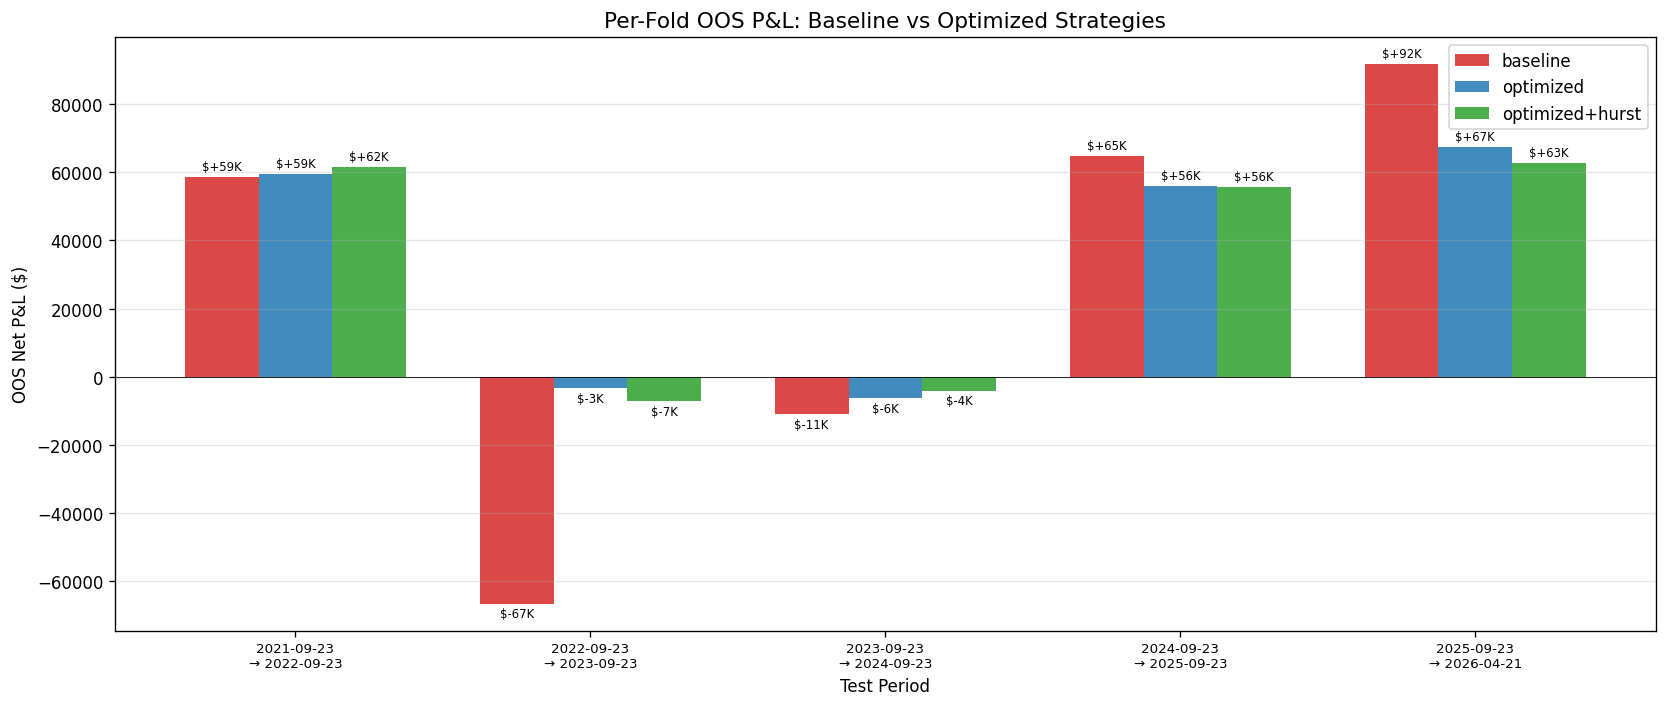

Bear market year (Sep 2022 → Sep 2023):
  baseline              : $-66,553 (SR -2.11, DD $85,411)
  optimized             : $-3,285 (SR -0.15, DD $25,234)
  optimized+hurst       : $-7,190 (SR -0.33, DD $28,490)

Total over 5 OOS years:
  baseline              : $+137,678, SR 1.02, DD $105,698, DSR 14%
  optimized             : $+173,118, SR 1.74, DD $39,809, DSR 45%
  optimized+hurst       : $+168,576, SR 1.73, DD $37,425, DSR 44%


In [28]:
# Per-fold comparison: baseline vs optimized vs optimized+hurst
top_variants = {
    'baseline': improvement_results['baseline_3pair'],
    'optimized': improvement_results['optimized'],
    'optimized+hurst': improvement_results['optimized+hurst'],
}

fig, ax = plt.subplots(figsize=(14, 6))

ref = top_variants['optimized']
n_folds = len(ref.windows)
test_labels = [f'{w.test_start}\n→ {w.test_end}' for w in ref.windows]

x = np.arange(n_folds)
width = 0.25
colors_top = {'baseline': 'tab:red', 'optimized': 'tab:blue', 'optimized+hurst': 'tab:green'}

for j, (name, wf) in enumerate(top_variants.items()):
    nets = [w.test_net for w in wf.windows]
    offset = (j - 1) * width
    bars = ax.bar(x + offset, nets, width, label=name, color=colors_top[name], alpha=0.85)
    for xi, v in zip(x + offset, nets):
        ax.text(xi, v + (2000 if v >= 0 else -4000), f'${v/1000:+.0f}K',
                ha='center', fontsize=7)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Test Period')
ax.set_ylabel('OOS Net P&L ($)')
ax.set_title('Per-Fold OOS P&L: Baseline vs Optimized Strategies', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(test_labels, fontsize=8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# The key story: bear market survival
print('Bear market year (Sep 2022 → Sep 2023):')
for name, wf in top_variants.items():
    w = wf.windows[1]
    print(f'  {name:22s}: ${w.test_net:+,.0f} (SR {w.test_sharpe:+.2f}, DD ${w.test_max_dd:,.0f})')
print()
print('Total over 5 OOS years:')
for name, wf in top_variants.items():
    print(f'  {name:22s}: ${wf.oos_net:+,.0f}, SR {wf.oos_sharpe:.2f}, DD ${wf.oos_max_dd:,.0f}, DSR {wf.dsr*100:.0f}%')

  baseline: 2040 trades


  optimized: 1517 trades


  optimized+hurst: 1452 trades


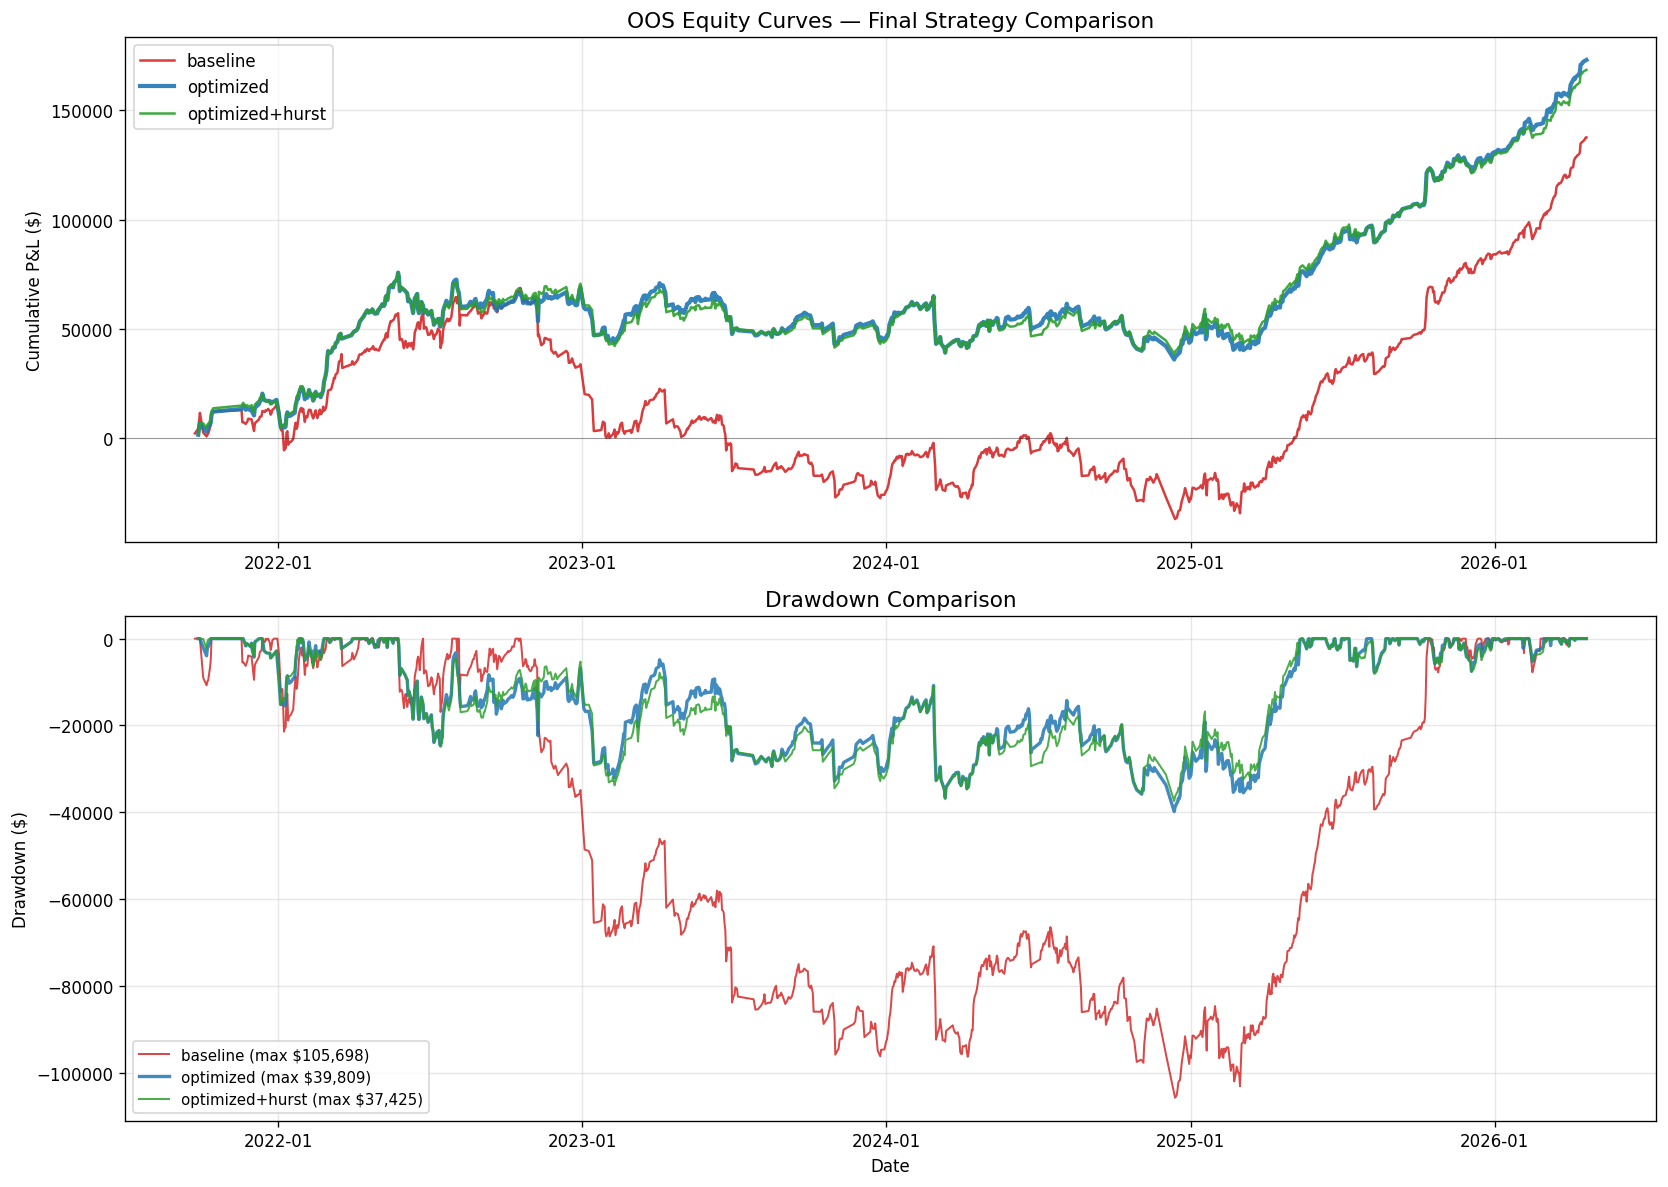

baseline: Final $+137,678, Best day $+8,976, Worst day $-15,439, Skew -2.44, Kurt 12.3
optimized: Final $+173,118, Best day $+9,872, Worst day $-11,498, Skew -1.23, Kurt 7.0
optimized+hurst: Final $+168,576, Best day $+9,872, Worst day $-11,900, Skew -1.39, Kurt 8.3


In [29]:
# OOS equity curves for final strategies
print('Collecting OOS trades for final comparison...')
trades_final = {}
for name, config in [('baseline', base),
                     ('optimized', cfg_replace(base, entry_z=2.5, max_hold_hours=36,
                                               progress_exit_hours=12, progress_exit_pct=0.10)),
                     ('optimized+hurst', cfg_replace(base, entry_z=2.5, hurst_threshold=0.55,
                                                     max_hold_hours=36, progress_exit_hours=12,
                                                     progress_exit_pct=0.10))]:
    trades_final[name] = collect_oos_trades(prices, config, funding, 1, 12, 12)
    print(f'  {name}: {len(trades_final[name])} trades')

eq_final = {name: trades_to_equity(trades) for name, trades in trades_final.items()}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Equity curves
colors_f = {'baseline': 'tab:red', 'optimized': 'tab:blue', 'optimized+hurst': 'tab:green'}
for name, eq in eq_final.items():
    if eq.empty:
        continue
    lw = 2.5 if name == 'optimized' else 1.5
    ax1.plot(eq['date'], eq['cumulative_pnl'], label=name, color=colors_f[name], linewidth=lw, alpha=0.9)

ax1.axhline(0, color='black', linewidth=0.5, alpha=0.4)
ax1.set_title('OOS Equity Curves — Final Strategy Comparison', fontsize=13)
ax1.set_ylabel('Cumulative P&L ($)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Drawdowns
for name, eq in eq_final.items():
    if eq.empty:
        continue
    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    lw = 2.0 if name == 'optimized' else 1.2
    ax2.plot(eq['date'], -dd, label=f'{name} (max ${dd.max():,.0f})',
             color=colors_f[name], linewidth=lw, alpha=0.85)

ax2.set_title('Drawdown Comparison', fontsize=13)
ax2.set_ylabel('Drawdown ($)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

# Final stats
for name, eq in eq_final.items():
    if eq.empty:
        continue
    d = eq['daily_pnl']
    print(f'{name}: Final ${eq["cumulative_pnl"].iloc[-1]:+,.0f}, '
          f'Best day ${d.max():+,.0f}, Worst day ${d.min():+,.0f}, '
          f'Skew {d.skew():.2f}, Kurt {d.kurtosis():.1f}')

## P&L Path Comparison — Portfolio Sets and Strategies

This section compares the realized out-of-sample equity curves over time for the strongest candidates we have so far:
- `original_3_optimized`
- `original_3+ADA_optimized`
- `new_top4_optimized`
- `original_3_optimized_hurst`
- `original_3_baseline`

The goal is to make the path tradeoff obvious: total return, time underwater, and how quickly each candidate starts compounding.

/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/2068083140.py:61: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/2068083140.py:61: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/2068083140.py:61: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/2068083140.py:61: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/2068083140.py:61: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


,Candidate,Final P&L,Max DD,Worst month,Best month,Longest underwater (days),First date above $100k
3,original_3+ADA_optimized,"$+239,889","$43,130","$-26,558","$+24,574",278,2023-06-09
4,new_top4_optimized,"$+235,265","$50,093","$-21,035","$+29,056",230,2024-01-13
1,original_3_optimized,"$+173,118","$39,809","$-23,016","$+17,728",637,2025-08-31
2,original_3_optimized_hurst,"$+168,576","$37,425","$-26,272","$+17,213",620,2025-08-31
0,original_3_baseline,"$+137,678","$105,698","$-33,672","$+21,944",742,2026-02-28


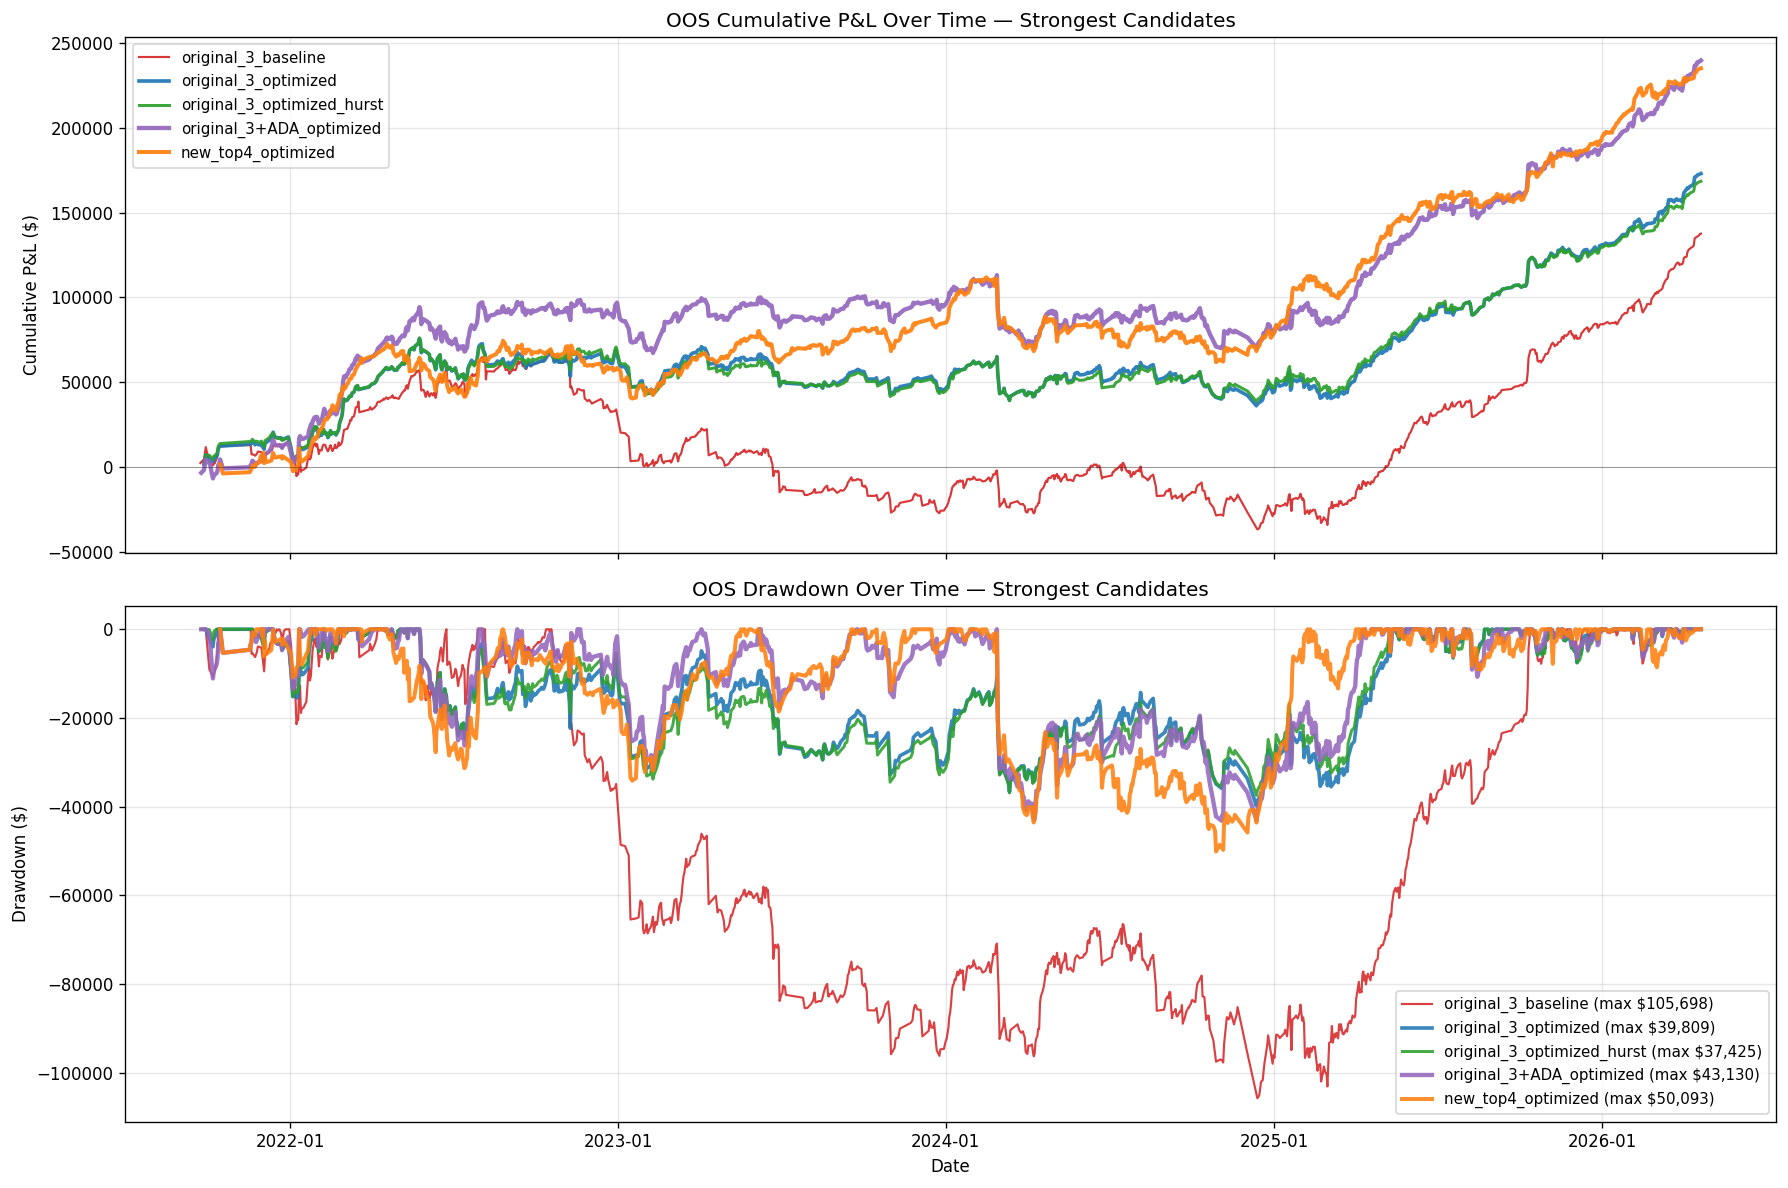

Path takeaways:
  original_3+ADA_optimized    final $+239,889, DD $43,130, underwater 278d, first >$100k: 2023-06-09
  new_top4_optimized          final $+235,265, DD $50,093, underwater 230d, first >$100k: 2024-01-13
  original_3_optimized        final $+173,118, DD $39,809, underwater 637d, first >$100k: 2025-08-31
  original_3_optimized_hurst  final $+168,576, DD $37,425, underwater 620d, first >$100k: 2025-08-31
  original_3_baseline         final $+137,678, DD $105,698, underwater 742d, first >$100k: 2026-02-28


In [30]:
curve_candidates = {
    'original_3_baseline': (
        prices,
        funding,
        base,
        1,
    ),
    'original_3_optimized': (
        prices,
        funding,
        cfg_replace(base, entry_z=2.5, max_hold_hours=36,
                    progress_exit_hours=12, progress_exit_pct=0.10),
        1,
    ),
    'original_3_optimized_hurst': (
        prices,
        funding,
        cfg_replace(base, entry_z=2.5, hurst_threshold=0.55,
                    max_hold_hours=36, progress_exit_hours=12, progress_exit_pct=0.10),
        1,
    ),
    'original_3+ADA_optimized': (
        *build_aligned_exp(sorted(set(c for pair in portfolios_viable['original_3+ADA'] for c in pair))),
        StrategyConfig(
            pairs=tuple(PairConfig(a, b) for a, b in portfolios_viable['original_3+ADA']),
            **opt_base_kw,
        ),
        1,
    ),
    'new_top4_optimized': (
        *build_aligned_exp(sorted(set(c for pair in portfolios_viable['new_top4 (w/ NEAR/DOT)'] for c in pair))),
        StrategyConfig(
            pairs=tuple(PairConfig(a, b) for a, b in portfolios_viable['new_top4 (w/ NEAR/DOT)']),
            **opt_base_kw,
        ),
        1,
    ),
}

curve_equity = {}
curve_summary_rows = []

for name, (curve_prices, curve_funding, curve_config, train_years) in curve_candidates.items():
    trades = collect_oos_trades(curve_prices, curve_config, curve_funding, train_years, 12, 12)
    eq = trades_to_equity(trades)
    curve_equity[name] = eq
    if eq.empty:
        continue

    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    under = dd > 0
    longest = cur = 0
    for flag in under:
        if flag:
            cur += 1
            longest = max(longest, cur)
        else:
            cur = 0

    monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()
    first_100k = eq.loc[eq['cumulative_pnl'] >= 100_000, 'date']

    curve_summary_rows.append({
        'Candidate': name,
        'Final P&L': eq['cumulative_pnl'].iloc[-1],
        'Max DD': dd.max(),
        'Worst month': monthly.min(),
        'Best month': monthly.max(),
        'Longest underwater (days)': longest,
        'First date above $100k': first_100k.iloc[0].date().isoformat() if not first_100k.empty else 'never',
    })

curve_summary = pd.DataFrame(curve_summary_rows).sort_values('Final P&L', ascending=False)
display(curve_summary.style.format({
    'Final P&L': '${:+,.0f}',
    'Max DD': '${:,.0f}',
    'Worst month': '${:+,.0f}',
    'Best month': '${:+,.0f}',
    'Longest underwater (days)': '{:.0f}',
}))

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
colors = {
    'original_3_baseline': 'tab:red',
    'original_3_optimized': 'tab:blue',
    'original_3_optimized_hurst': 'tab:green',
    'original_3+ADA_optimized': 'tab:purple',
    'new_top4_optimized': 'tab:orange',
}
widths = {
    'original_3_baseline': 1.3,
    'original_3_optimized': 2.2,
    'original_3_optimized_hurst': 1.8,
    'original_3+ADA_optimized': 2.6,
    'new_top4_optimized': 2.4,
}

for name, eq in curve_equity.items():
    if eq.empty:
        continue
    axes[0].plot(eq['date'], eq['cumulative_pnl'], label=name, color=colors[name], linewidth=widths[name], alpha=0.92)
    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    axes[1].plot(eq['date'], -dd, label=f"{name} (max ${dd.max():,.0f})", color=colors[name], linewidth=widths[name], alpha=0.88)

axes[0].axhline(0, color='black', linewidth=0.5, alpha=0.4)
axes[0].set_title('OOS Cumulative P&L Over Time — Strongest Candidates')
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='upper left')

axes[1].set_title('OOS Drawdown Over Time — Strongest Candidates')
axes[1].set_ylabel('Drawdown ($)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, loc='lower right')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

print('Path takeaways:')
for _, row in curve_summary.iterrows():
    print(
        f"  {row['Candidate']:26s}  final ${row['Final P&L']:+,.0f}, "
        f"DD ${row['Max DD']:,.0f}, underwater {int(row['Longest underwater (days)'])}d, "
        f"first >$100k: {row['First date above $100k']}"
    )


## Finalists Validation — Shared Window and Untouched Holdout

This is the cleanest apples-to-apples comparison so far.

We restrict the universe to the three finalist portfolio sets:
- `original_3_optimized`
- `original_3+ADA_optimized`
- `new_top4_optimized`

Then we:
- align all three to the same common time window
- run a strict finalists-only walk-forward on the pre-holdout sample
- reserve the final 12 months as a completely untouched holdout and compare all three directly

This does not fully solve search bias, but it is much stronger evidence than comparing raw backtest endpoints alone.

In [31]:
finalists = {
    'original_3_optimized': [('LINK','SOL'),('DOGE','AVAX'),('SOL','AVAX')],
    'original_3+ADA_optimized': [('LINK','SOL'),('DOGE','AVAX'),('SOL','AVAX'),('DOGE','ADA')],
    'new_top4_optimized': [('DOGE','AVAX'),('SOL','LINK'),('NEAR','DOT'),('DOGE','ADA')],
}

all_finalist_coins = sorted({c for pairs in finalists.values() for pair in pairs for c in pair})


def load_coin_close(coin):
    for d in [repo_root / 'data' / 'market' / 'binance_futures' / 'expanded' / 'candles', repo_root / 'data' / 'binance_6y' / 'candles']:
        fp = d / f'{coin}_1h.csv'
        if fp.exists():
            df = pd.read_csv(fp)
            ts = df['timestamp']
            dt = pd.to_datetime(ts, unit='ms' if ts.iloc[0] > 1e12 else 's', utc=True)
            return df.assign(datetime=dt).set_index('datetime')['close'].astype(float)
    raise FileNotFoundError(coin)


def load_coin_funding(coin):
    for d in [repo_root / 'data' / 'market' / 'binance_futures' / 'expanded' / 'funding', repo_root / 'data' / 'binance_6y' / 'funding']:
        fp = d / f'{coin}_1h.csv'
        if fp.exists():
            df = pd.read_csv(fp)
            ts = df['timestamp']
            dt = pd.to_datetime(ts, unit='ms' if ts.iloc[0] > 1e12 else 's', utc=True)
            return df.assign(datetime=dt).set_index('datetime')['funding_rate'].astype(float)
    raise FileNotFoundError(coin)

final_price_map = {c: load_coin_close(c) for c in all_finalist_coins}
final_idx = None
for s in final_price_map.values():
    final_idx = s.index if final_idx is None else final_idx.intersection(s.index)

final_prices = pd.DataFrame({c: final_price_map[c].loc[final_idx] for c in all_finalist_coins}).sort_index()
final_funding = pd.DataFrame({c: load_coin_funding(c).reindex(final_idx).ffill() for c in all_finalist_coins}).sort_index()

finalist_configs = {
    name: StrategyConfig(
        pairs=tuple(PairConfig(a, b) for a, b in pairs),
        **opt_base_kw,
    )
    for name, pairs in finalists.items()
}

holdout_end = final_prices.index[-1]
holdout_start = holdout_end - pd.DateOffset(months=12)
research_prices = final_prices[final_prices.index < holdout_start]
research_funding = final_funding[final_funding.index < holdout_start]
base_finalist = next(iter(finalist_configs.values()))

strict_finalists = run_walk_forward(
    research_prices,
    base_finalist,
    funding=research_funding,
    train_years=1,
    test_months=12,
    step_months=12,
    candidate_configs=finalist_configs,
    selection_metric='sharpe',
)

strict_rows = []
for w in strict_finalists.windows:
    strict_rows.append({
        'Fold': w.fold,
        'Selected on train': w.selected_config,
        'Test Period': f'{w.test_start} → {w.test_end}',
        'Test SR': w.test_sharpe,
        'Test Net': w.test_net,
        'Test DD': w.test_max_dd,
        'Trades': w.test_trades,
    })

display(pd.DataFrame(strict_rows).style.format({
    'Test SR': '{:.2f}',
    'Test Net': '${:+,.0f}',
    'Test DD': '${:,.0f}',
}))

print('STRICT FINALISTS WALK-FORWARD')
print(f'  Common window: {final_prices.index[0]} → {final_prices.index[-1]} ({len(final_prices):,} bars)')
print(f'  Research window: {research_prices.index[0]} → {research_prices.index[-1]} ({len(research_prices):,} bars)')
print(f'  OOS net: ${strict_finalists.oos_net:+,.0f}')
print(f'  OOS Sharpe: {strict_finalists.oos_sharpe:.2f}')
print(f'  OOS max DD: ${strict_finalists.oos_max_dd:,.0f}')
print(f'  PSR: {strict_finalists.psr*100:.1f}%')
print(f'  DSR ({strict_finalists.n_trials} trials): {strict_finalists.dsr*100:.1f}%')
print(pd.Series([w.selected_config for w in strict_finalists.windows]).value_counts().to_string())

holdout_rows = []
warmup = max(base_finalist.lookback_hours, base_finalist.corr_window_hours) + 10
for name, cfg in finalist_configs.items():
    warm_start = holdout_start - pd.Timedelta(hours=warmup)
    p = final_prices[warm_start:holdout_end]
    f = final_funding[(final_funding.index >= warm_start) & (final_funding.index <= holdout_end)]
    trades = run_backtest_all_pairs(p, cfg, funding=f)
    holdout_start_ms = int(final_prices[final_prices.index >= holdout_start].index[0].timestamp() * 1000)
    trades = [t for t in trades if t.entry_ts >= holdout_start_ms]
    eq = trades_to_equity(trades)
    if eq.empty:
        continue
    peak = eq['cumulative_pnl'].cummax()
    dd = peak - eq['cumulative_pnl']
    under = dd > 0
    longest = cur = 0
    for flag in under:
        if flag:
            cur += 1
            longest = max(longest, cur)
        else:
            cur = 0
    monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()
    idx_days = pd.date_range(holdout_start.normalize(), holdout_end.normalize(), freq='D', tz='UTC')
    daily_series = eq.set_index('date')['daily_pnl'].reindex(idx_days, fill_value=0.0)
    holdout_rows.append({
        'Candidate': name,
        'Trades': len(trades),
        'Holdout Net': eq['cumulative_pnl'].iloc[-1],
        'Holdout Max DD': dd.max(),
        'Worst month': monthly.min(),
        'Best month': monthly.max(),
        'Underwater days': longest,
        'PSR': probabilistic_sharpe_ratio(daily_series.tolist()) * 100,
        'DSR': deflated_sharpe_ratio(daily_series.tolist(), n_trials=len(finalist_configs)) * 100,
        'Sortino': sortino_ratio(daily_series.tolist()),
        'CVaR 95%': conditional_var(daily_series.tolist(), 0.05),
    })

holdout_df = pd.DataFrame(holdout_rows).sort_values(['Holdout Net', 'Sortino'], ascending=[False, False])
display(holdout_df.style.format({
    'Holdout Net': '${:+,.0f}',
    'Holdout Max DD': '${:,.0f}',
    'Worst month': '${:+,.0f}',
    'Best month': '${:+,.0f}',
    'Underwater days': '{:.0f}',
    'PSR': '{:.1f}%',
    'DSR': '{:.1f}%',
    'Sortino': '{:.2f}',
    'CVaR 95%': '${:,.0f}',
}))

print(f'HOLDOUT WINDOW: {holdout_start} → {holdout_end}')


,Fold,Selected on train,Test Period,Test SR,Test Net,Test DD,Trades
0,0,original_3_optimized,2021-10-15 → 2022-10-15,2.40,"$+53,183","$24,720",309
1,1,original_3_optimized,2022-10-15 → 2023-10-15,-0.66,"$-13,922","$25,234",311
2,2,original_3_optimized,2023-10-15 → 2024-10-15,-0.10,"$-2,249","$25,890",297
3,3,original_3_optimized,2024-10-15 → 2025-04-21,1.18,"$+15,123","$16,342",176


STRICT FINALISTS WALK-FORWARD
  Common window: 2020-10-15 08:00:00+00:00 → 2026-04-21 17:00:00+00:00 (48,346 bars)
  Research window: 2020-10-15 08:00:00+00:00 → 2025-04-21 16:00:00+00:00 (39,585 bars)
  OOS net: $+52,135
  OOS Sharpe: 0.67
  OOS max DD: $38,133
  PSR: 82.3%
  DSR (1215 trials): 1.1%
original_3_optimized    4


/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/1732823161.py:114: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/1732823161.py:114: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


/var/folders/l7/_27wq1b120nfz7ktg9rc2z440000gn/T/ipykernel_36611/1732823161.py:114: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = eq.assign(month=eq['date'].dt.to_period('M').astype(str)).groupby('month')['daily_pnl'].sum()


,Candidate,Trades,Holdout Net,Holdout Max DD,Worst month,Best month,Underwater days,PSR,DSR,Sortino,CVaR 95%
1,original_3+ADA_optimized,566,"$+121,158","$10,715","$-1,919","$+17,867",36,100.0%,100.0%,4.42,"$3,175"
2,new_top4_optimized,587,"$+113,131","$9,105","$-4,910","$+19,551",55,100.0%,99.7%,3.69,"$3,783"
0,original_3_optimized,407,"$+107,959","$7,696","$+3,609","$+16,755",25,100.0%,100.0%,4.62,"$2,620"


HOLDOUT WINDOW: 2025-04-21 17:00:00+00:00 → 2026-04-21 17:00:00+00:00


## Finalist Scorecard

This is the compact decision view.

It combines three ideas:
- full OOS path quality: does the curve compound early and avoid very long flat/down periods?
- strict finalists-only walk-forward: which candidate kept winning when forced to compete fairly inside the shared pre-holdout sample?
- untouched holdout: which candidate actually delivered the best future performance over the final 12 months?

Interpretation:
- higher `Full OOS Net` and `Holdout Net` are better
- lower `Full OOS Max DD`, `Holdout Max DD`, and `Underwater days` are better
- more `Strict fold wins` means the candidate was chosen more often by the train-only selector
- the final verdict is qualitative, not a theorem

In [32]:
curve_lookup = curve_summary.set_index('Candidate')
strict_wins = pd.Series([w.selected_config for w in strict_finalists.windows]).value_counts()
holdout_lookup = holdout_df.set_index('Candidate')

scorecard_rows = []
for candidate in holdout_lookup.index:
    full_row = curve_lookup.loc[candidate]
    hold_row = holdout_lookup.loc[candidate]
    fold_wins = int(strict_wins.get(candidate, 0))

    if candidate == 'original_3_optimized':
        verdict = 'Most robust / simplest winner so far'
    elif candidate == 'original_3+ADA_optimized':
        verdict = 'Best holdout return / strongest upside candidate'
    else:
        verdict = 'Strong contender / good path but not clear #1'

    scorecard_rows.append({
        'Candidate': candidate,
        'Full OOS Net': full_row['Final P&L'],
        'Full OOS Max DD': full_row['Max DD'],
        'Full OOS Underwater days': full_row['Longest underwater (days)'],
        'First > $100k': full_row['First date above $100k'],
        'Strict fold wins': fold_wins,
        'Holdout Net': hold_row['Holdout Net'],
        'Holdout Max DD': hold_row['Holdout Max DD'],
        'Holdout Underwater days': hold_row['Underwater days'],
        'Holdout Sortino': hold_row['Sortino'],
        'Verdict': verdict,
    })

scorecard = pd.DataFrame(scorecard_rows)

# simple transparent ranking: 40% holdout net rank, 30% strict fold-win rank,
# 20% full OOS underwater rank, 10% holdout DD rank
scorecard['rank_holdout_net'] = scorecard['Holdout Net'].rank(ascending=False, method='min')
scorecard['rank_strict_wins'] = scorecard['Strict fold wins'].rank(ascending=False, method='min')
scorecard['rank_full_underwater'] = scorecard['Full OOS Underwater days'].rank(ascending=True, method='min')
scorecard['rank_holdout_dd'] = scorecard['Holdout Max DD'].rank(ascending=True, method='min')
scorecard['overall_rank'] = (
    0.40 * scorecard['rank_holdout_net']
    + 0.30 * scorecard['rank_strict_wins']
    + 0.20 * scorecard['rank_full_underwater']
    + 0.10 * scorecard['rank_holdout_dd']
)
scorecard = scorecard.sort_values(['overall_rank', 'Holdout Net'], ascending=[True, False]).reset_index(drop=True)

display(scorecard[[
    'Candidate',
    'Full OOS Net',
    'Full OOS Max DD',
    'Full OOS Underwater days',
    'First > $100k',
    'Strict fold wins',
    'Holdout Net',
    'Holdout Max DD',
    'Holdout Underwater days',
    'Holdout Sortino',
    'Verdict',
]].style.format({
    'Full OOS Net': '${:+,.0f}',
    'Full OOS Max DD': '${:,.0f}',
    'Full OOS Underwater days': '{:.0f}',
    'Strict fold wins': '{:.0f}',
    'Holdout Net': '${:+,.0f}',
    'Holdout Max DD': '${:,.0f}',
    'Holdout Underwater days': '{:.0f}',
    'Holdout Sortino': '{:.2f}',
}))

print('Ranking takeaway:')
for _, row in scorecard.iterrows():
    print(
        f"  {row['Candidate']:26s} rank {row['overall_rank']:.2f} | "
        f"strict wins {int(row['Strict fold wins'])}, holdout ${row['Holdout Net']:+,.0f}, "
        f"full underwater {int(row['Full OOS Underwater days'])}d"
    )


,Candidate,Full OOS Net,Full OOS Max DD,Full OOS Underwater days,First > $100k,Strict fold wins,Holdout Net,Holdout Max DD,Holdout Underwater days,Holdout Sortino,Verdict
0,original_3+ADA_optimized,"$+239,889","$43,130",278,2023-06-09,0,"$+121,158","$10,715",36,4.42,Best holdout return / strongest upside candidate
1,new_top4_optimized,"$+235,265","$50,093",230,2024-01-13,0,"$+113,131","$9,105",55,3.69,Strong contender / good path but not clear #1
2,original_3_optimized,"$+173,118","$39,809",637,2025-08-31,4,"$+107,959","$7,696",25,4.62,Most robust / simplest winner so far


Ranking takeaway:
  original_3+ADA_optimized   rank 1.70 | strict wins 0, holdout $+121,158, full underwater 278d
  new_top4_optimized         rank 1.80 | strict wins 0, holdout $+113,131, full underwater 230d
  original_3_optimized       rank 2.20 | strict wins 4, holdout $+107,959, full underwater 637d
